# Probabilistic Calibration Study for Probabilistic LSTM Models

This notebook reuses the existing probabilistic LSTM model class, preprocessing pipeline, and checkpoint naming conventions from the group codebase. Section 0 builds an inference bridge that loads the saved probabilistic LSTM checkpoints, caches test-set predictions, and exposes the exact arrays required for the calibration study. Sections 1-8 then perform the requested probabilistic diagnostics, likelihood comparisons, and rolling analyses.


In [15]:
import ast
import json
import random
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from scipy import optimize, stats
from sklearn.preprocessing import RobustScaler
from statsmodels.stats.diagnostic import acorr_ljungbox
from torch.utils.data import DataLoader, Dataset

try:
    from arch import arch_model
except ImportError as exc:
    raise ImportError("This notebook requires the 'arch' package for Section 5.") from exc

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pd.options.display.float_format = lambda x: f"{x:.4f}"
np.set_printoptions(precision=4, suppress=True)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
    }
)

MODEL_COLORS = {
    "NLL LSTM": "blue",
    "Composite LSTM": "orange",
    "GARCH(1,1)": "green",
}
ACTUAL_COLOR = "dimgray"
REFERENCE_COLOR = "black"
REFERENCE_STYLE = "--"
AD_N_MC = 9999

print(f"Using device: {DEVICE}")
print(f"Random seed: {SEED}")


Using device: cpu
Random seed: 42


## Preflight

This preflight check locates the project root from the current working directory, creates the output directory used by this notebook, and verifies that the expected probabilistic LSTM checkpoints exist. The notebook is intentionally strict here: if the trained checkpoint files are absent, execution stops immediately with a clear error instead of silently retraining or drifting away from the original group pipeline.


In [2]:
def find_project_root(start_path: Path) -> Path:
    start_path = start_path.resolve()
    for candidate in [start_path] + list(start_path.parents):
        if (candidate / "scripts" / "grid_search_nll.py").exists() and (candidate / "data" / "processed").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing scripts/grid_search_nll.py and data/processed/.")


PROJECT_DIR = find_project_root(Path.cwd())
NOTEBOOK_DIR = PROJECT_DIR / "notebooks" / "daily" / "return_prediction"
OUTPUT_DIR = NOTEBOOK_DIR
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PREDICTIONS_CSV = OUTPUT_DIR / "test_predictions.csv"

SOURCE_SCRIPT = PROJECT_DIR / "scripts" / "grid_search_nll.py"
DATASET_PATH = PROJECT_DIR / "data" / "processed" / "sanity_data_pca.parquet"
RESULTS_DIR = PROJECT_DIR / "results" / "nll_grid"

CHECKPOINT_PATHS = {
    "NLL LSTM": RESULTS_DIR / "lstm_nll_model.pth",
    "Composite LSTM": RESULTS_DIR / "lstm_nll_dir_var_model.pth",
}
PARAMS_PATHS = {
    "NLL LSTM": RESULTS_DIR / "lstm_nll_best_params.json",
    "Composite LSTM": RESULTS_DIR / "lstm_nll_dir_var_best_params.json",
}
FALLBACK_PARAMS = {
    "NLL LSTM": {
        "seq_len": 3,
        "hidden_size": 128,
        "num_layers": 3,
        "dropout": 0.0,
        "learning_rate": 1e-3,
    },
    "Composite LSTM": {
        "seq_len": 5,
        "hidden_size": 128,
        "num_layers": 2,
        "dropout": 0.3,
        "learning_rate": 5e-4,
    },
}

missing_checkpoints = [str(path) for path in CHECKPOINT_PATHS.values() if not path.exists()]
if missing_checkpoints:
    raise FileNotFoundError(
        "Missing probabilistic LSTM checkpoint file(s). Place the trained weights at the expected saved paths before running this notebook:\n"
        + "\n".join(f"- {path}" for path in missing_checkpoints)
    )


def load_inference_params(label: str) -> dict:
    params = FALLBACK_PARAMS[label].copy()
    params_path = PARAMS_PATHS[label]
    if params_path.exists():
        with params_path.open("r", encoding="utf-8") as handle:
            raw = json.load(handle)
        params.update(
            {
                "seq_len": int(raw.get("seq_len", params["seq_len"])),
                "hidden_size": int(raw.get("hidden_size", params["hidden_size"])),
                "num_layers": int(raw.get("num_layers", params["num_layers"])),
                "dropout": float(raw.get("dropout", params["dropout"])),
                "learning_rate": float(raw.get("learning_rate", params["learning_rate"])),
            }
        )
        used_fallback = False
    else:
        used_fallback = True
    params["used_fallback_params"] = used_fallback
    params["checkpoint_path"] = CHECKPOINT_PATHS[label]
    params["params_path"] = params_path if params_path.exists() else None
    return params


NLL_PARAMS = load_inference_params("NLL LSTM")
COMP_PARAMS = load_inference_params("Composite LSTM")

print(f"Project directory: {PROJECT_DIR}")
print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Dataset path: {DATASET_PATH}")
print(f"Output CSV: {PREDICTIONS_CSV}")
print(f"Figures directory: {FIGURES_DIR}")
for label, params in [("NLL LSTM", NLL_PARAMS), ("Composite LSTM", COMP_PARAMS)]:
    print(f"{label} checkpoint: {params['checkpoint_path']}")
    if params["used_fallback_params"]:
        print(f"{label} params JSON missing at {PARAMS_PATHS[label]}; using fallback hyperparameters from scripts/_plot_final.py.")
    else:
        print(f"{label} params JSON: {params['params_path']}")


Project directory: C:\Users\peter\Documents\GitHub\datascienceproject
Notebook directory: C:\Users\peter\Documents\GitHub\datascienceproject\notebooks\daily\return_prediction
Dataset path: C:\Users\peter\Documents\GitHub\datascienceproject\data\processed\sanity_data_pca.parquet
Output CSV: C:\Users\peter\Documents\GitHub\datascienceproject\notebooks\daily\return_prediction\test_predictions.csv
Figures directory: C:\Users\peter\Documents\GitHub\datascienceproject\notebooks\daily\return_prediction\figures
NLL LSTM checkpoint: C:\Users\peter\Documents\GitHub\datascienceproject\results\nll_grid\lstm_nll_model.pth
NLL LSTM params JSON: C:\Users\peter\Documents\GitHub\datascienceproject\results\nll_grid\lstm_nll_best_params.json
Composite LSTM checkpoint: C:\Users\peter\Documents\GitHub\datascienceproject\results\nll_grid\lstm_nll_dir_var_model.pth
Composite LSTM params JSON: C:\Users\peter\Documents\GitHub\datascienceproject\results\nll_grid\lstm_nll_dir_var_best_params.json


## Section 0 - Inference Bridge

This section recreates the exact probabilistic LSTM inference path used in the group codebase. It extracts the existing model and sequence helpers directly from `scripts/grid_search_nll.py`, rebuilds the original train/validation/test split on `sanity_data_pca.parquet`, loads the two trained probabilistic LSTM checkpoints, and caches the resulting test-set predictions to `test_predictions.csv` for downstream analysis.


In [3]:
TARGET_SYMBOLS = [
    "create_sequences",
    "create_sequences_with_bridge",
    "OilDataset",
    "LSTMModelNLL",
    "pure_nll",
    "nll_dir_var",
]

source_text = SOURCE_SCRIPT.read_text(encoding="utf-8")
source_tree = ast.parse(source_text)
extracted_segments = {}
for node in source_tree.body:
    if isinstance(node, (ast.FunctionDef, ast.ClassDef)) and node.name in TARGET_SYMBOLS:
        extracted_segments[node.name] = ast.get_source_segment(source_text, node)

missing_symbols = [name for name in TARGET_SYMBOLS if name not in extracted_segments]
if missing_symbols:
    raise RuntimeError(f"Could not extract the required symbols from {SOURCE_SCRIPT}: {missing_symbols}")

exec_namespace = {}
exec("\n\n".join(extracted_segments[name] for name in TARGET_SYMBOLS), globals(), exec_namespace)
for symbol_name in TARGET_SYMBOLS:
    globals()[symbol_name] = exec_namespace[symbol_name]

print("Extracted repository symbols:")
print(", ".join(TARGET_SYMBOLS))

TARGET = "Target"
NON_FEATURE_COLS = ["Date", "Target", "WTI_Close", "Brent_Close"]
TRAIN_END = "2022-12-31"
VAL_END = "2024-06-30"

raw_df = pd.read_parquet(DATASET_PATH)
raw_df["Date"] = pd.to_datetime(raw_df["Date"])
FEATURE_COLS = [column for column in raw_df.columns if column not in NON_FEATURE_COLS]
df = raw_df.dropna(subset=[TARGET] + FEATURE_COLS).reset_index(drop=True)

train_df = df[df["Date"] <= TRAIN_END].copy()
val_df = df[(df["Date"] > TRAIN_END) & (df["Date"] <= VAL_END)].copy()
test_df = df[df["Date"] > VAL_END].copy()

scaler_X = RobustScaler()
scaler_y = RobustScaler()
train_X = scaler_X.fit_transform(train_df[FEATURE_COLS].values)
train_y = scaler_y.fit_transform(train_df[[TARGET]].values).flatten()
val_X = scaler_X.transform(val_df[FEATURE_COLS].values)
val_y = scaler_y.transform(val_df[[TARGET]].values).flatten()
test_X = scaler_X.transform(test_df[FEATURE_COLS].values)
test_y = scaler_y.transform(test_df[[TARGET]].values).flatten()

n_features = len(FEATURE_COLS)
train_returns = train_df[TARGET].to_numpy(copy=True)
val_returns = val_df[TARGET].to_numpy(copy=True)

print(f"Processed dataset shape: {df.shape}")
print(f"Number of features: {n_features}")
print(f"Train rows: {len(train_df)} | Validation rows: {len(val_df)} | Test rows: {len(test_df)}")


def extract_state_dict(checkpoint_object):
    if isinstance(checkpoint_object, dict):
        if checkpoint_object and all(torch.is_tensor(value) for value in checkpoint_object.values()):
            return checkpoint_object
        for key in ("state_dict", "model_state_dict", "model"):
            if key in checkpoint_object and isinstance(checkpoint_object[key], dict):
                return checkpoint_object[key]
    raise TypeError("Checkpoint format not recognised as a PyTorch state_dict.")


def normalise_state_dict_keys(state_dict: dict) -> dict:
    cleaned = {}
    for key, value in state_dict.items():
        cleaned_key = key[7:] if key.startswith("module.") else key
        cleaned[cleaned_key] = value
    return cleaned


def run_lstm_checkpoint_inference(params: dict, checkpoint_path: Path) -> dict:
    seq_len = int(params["seq_len"])
    hidden_size = int(params["hidden_size"])
    num_layers = int(params["num_layers"])
    dropout = float(params["dropout"])

    X_test_seq, y_test_seq = create_sequences_with_bridge(val_X, val_y, test_X, test_y, seq_len)
    test_loader = DataLoader(OilDataset(X_test_seq, y_test_seq), batch_size=32, shuffle=False)

    model = LSTMModelNLL(n_features, hidden_size, num_layers, dropout).to(DEVICE)
    checkpoint_object = torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
    state_dict = normalise_state_dict_keys(extract_state_dict(checkpoint_object))
    model.load_state_dict(state_dict)
    model.eval()

    mu_batches = []
    logvar_batches = []
    actual_batches = []
    with torch.no_grad():
        for features_batch, target_batch in test_loader:
            features_batch = features_batch.to(DEVICE)
            mu_batch, logvar_batch = model(features_batch)
            mu_batches.append(mu_batch.cpu().numpy())
            logvar_batches.append(logvar_batch.cpu().numpy())
            actual_batches.append(target_batch.numpy())

    mu_scaled = np.concatenate(mu_batches).flatten()
    logvar = np.concatenate(logvar_batches).flatten()
    actual_scaled = np.concatenate(actual_batches).flatten()

    mu = scaler_y.inverse_transform(mu_scaled.reshape(-1, 1)).flatten()
    r_true_local = scaler_y.inverse_transform(actual_scaled.reshape(-1, 1)).flatten()
    sigma = np.sqrt(np.exp(logvar)) * scaler_y.scale_[0]
    sigma = np.clip(sigma, 1e-8, None)
    date_local = pd.to_datetime(test_df["Date"].values[-len(r_true_local):])

    return {
        "date": date_local,
        "r_true": r_true_local,
        "mu": mu,
        "sigma": sigma,
        "logvar": logvar,
        "seq_len": seq_len,
    }


nll_inference = run_lstm_checkpoint_inference(NLL_PARAMS, CHECKPOINT_PATHS["NLL LSTM"])
comp_inference = run_lstm_checkpoint_inference(COMP_PARAMS, CHECKPOINT_PATHS["Composite LSTM"])

if not np.array_equal(nll_inference["date"].values.astype("datetime64[ns]"), comp_inference["date"].values.astype("datetime64[ns]")):
    raise RuntimeError("The NLL and composite inference dates do not align.")
if not np.allclose(nll_inference["r_true"], comp_inference["r_true"]):
    raise RuntimeError("The NLL and composite inference targets do not align.")

date = nll_inference["date"]
r_true = nll_inference["r_true"]
mu_nll = nll_inference["mu"]
sigma_nll = nll_inference["sigma"]
mu_comp = comp_inference["mu"]
sigma_comp = comp_inference["sigma"]
DATE_INDEX = pd.to_datetime(date)

inference_df = pd.DataFrame(
    {
        "date": pd.to_datetime(date),
        "r_true": r_true,
        "mu_nll": mu_nll,
        "sigma_nll": sigma_nll,
        "mu_comp": mu_comp,
        "sigma_comp": sigma_comp,
    }
)
inference_df.to_csv(PREDICTIONS_CSV, index=False)

sanity_table = pd.DataFrame(
    {
        "statistic": [
            "mean(r_true)",
            "std(r_true)",
            "mean(mu_nll)",
            "mean(sigma_nll)",
            "mean(mu_comp)",
            "mean(sigma_comp)",
        ],
        "value": [
            float(np.mean(r_true)),
            float(np.std(r_true, ddof=1)),
            float(np.mean(mu_nll)),
            float(np.mean(sigma_nll)),
            float(np.mean(mu_comp)),
            float(np.mean(sigma_comp)),
        ],
    }
)

supplemental_pred_std = pd.DataFrame(
    {
        "statistic": ["std(mu_nll)", "std(mu_comp)"],
        "value": [float(np.std(mu_nll, ddof=1)), float(np.std(mu_comp, ddof=1))],
    }
)

print(f"Cached inference outputs to: {PREDICTIONS_CSV}")
print(f"Test observations: {len(inference_df)}")
display(sanity_table)
print("Supplemental predicted-mean standard deviations used in the group scripts:")
display(supplemental_pred_std)


Extracted repository symbols:
create_sequences, create_sequences_with_bridge, OilDataset, LSTMModelNLL, pure_nll, nll_dir_var
Processed dataset shape: (1895, 55)
Number of features: 51
Train rows: 1235 | Validation rows: 312 | Test rows: 348
Cached inference outputs to: C:\Users\peter\Documents\GitHub\datascienceproject\notebooks\daily\return_prediction\test_predictions.csv
Test observations: 348


,statistic,value
0,mean(r_true),-0.0004
1,std(r_true),0.0230
2,mean(mu_nll),0.0009
3,mean(sigma_nll),0.0253
4,mean(mu_comp),0.0021
5,mean(sigma_comp),0.0307


Supplemental predicted-mean standard deviations used in the group scripts:


,statistic,value
0,std(mu_nll),0.0026
1,std(mu_comp),0.0143


### Interpretation Placeholder - Section 0

- Confirm that the cached test predictions were generated from the intended checkpoint files.
- Compare the sanity-check values against the group report once the real trained checkpoints are available in `results/nll_grid/`.


## Shared Analysis Helpers

The remaining sections reuse a common set of statistical and plotting helpers so that all calibration tests are applied consistently across the two LSTM variants and the GARCH benchmark. This cell defines those helpers once and keeps the later analysis cells focused on interpretation and results.


In [4]:
def format_date_axis(ax):
    locator = mdates.AutoDateLocator(minticks=5, maxticks=10)
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)


def rolling_realized_vol(values, date_index, window=60):
    return pd.Series(values, index=date_index).rolling(window=window, min_periods=window).std(ddof=1)


def summary_stats(values):
    values = np.asarray(values, dtype=float)
    return {
        "mean": float(np.mean(values)),
        "std": float(np.std(values, ddof=1)),
        "skewness": float(stats.skew(values, bias=False)),
        "excess_kurtosis": float(stats.kurtosis(values, fisher=True, bias=False)),
    }


def sample_acf(values, max_lag=40):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    centred = values - np.mean(values)
    denominator = np.dot(centred, centred)
    if denominator <= 0:
        return np.full(max_lag + 1, np.nan)
    acf_values = [1.0]
    for lag in range(1, max_lag + 1):
        acf_values.append(float(np.dot(centred[lag:], centred[:-lag]) / denominator))
    return np.asarray(acf_values)


def ljung_box_test(values, lag=10):
    values = np.asarray(values, dtype=float)
    n = len(values)
    acf_values = sample_acf(values, max_lag=lag)[1:]
    lags = np.arange(1, lag + 1)
    statistic = n * (n + 2) * np.sum((acf_values ** 2) / (n - lags))
    p_value = float(stats.chi2.sf(statistic, lag))
    return float(statistic), p_value


def plot_acf_panel(ax, values, title, color, max_lag=40):
    acf_values = sample_acf(values, max_lag=max_lag)
    lags = np.arange(1, max_lag + 1)
    band = 1.96 / np.sqrt(len(values))
    ax.axhline(0.0, color="black", linewidth=1.0)
    ax.vlines(lags, 0.0, acf_values[1:], color=color, linewidth=1.4)
    ax.plot(lags, acf_values[1:], marker="o", linestyle="-", color=color, label="ACF")
    ax.axhline(band, color=REFERENCE_COLOR, linestyle=REFERENCE_STYLE, linewidth=1.0, label="95% band")
    ax.axhline(-band, color=REFERENCE_COLOR, linestyle=REFERENCE_STYLE, linewidth=1.0)
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocorrelation")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)


def fit_gaussian_params(values):
    loc, scale = stats.norm.fit(values)
    return {"loc": float(loc), "scale": float(max(scale, 1e-8))}


def fit_student_t_full_params(values):
    df_t, loc_t, scale_t = stats.t.fit(values)
    return {
        "df": float(df_t),
        "loc": float(loc_t),
        "scale": float(max(scale_t, 1e-8)),
    }


def fit_standard_t_df(values):
    values = np.asarray(values, dtype=float)

    def objective(df_value):
        return -np.sum(stats.t.logpdf(values, df=df_value, loc=0.0, scale=1.0))

    result = optimize.minimize_scalar(objective, bounds=(2.01, 200.0), method="bounded")
    if not result.success:
        raise RuntimeError(f"Failed to fit Student-t degrees of freedom: {result.message}")
    return float(result.x)


def fit_standard_t_params(values):
    return {"df": fit_standard_t_df(values), "loc": 0.0, "scale": 1.0}


def anderson_darling_statistic(values, cdf_function):
    ordered = np.sort(np.asarray(values, dtype=float))
    ordered = ordered[np.isfinite(ordered)]
    n = len(ordered)
    if n < 2:
        return np.nan
    cdf_values = np.clip(cdf_function(ordered), 1e-10, 1 - 1e-10)
    i = np.arange(1, n + 1)
    return float(-n - np.sum((2 * i - 1) * (np.log(cdf_values) + np.log(1 - cdf_values[::-1]))) / n)


def parametric_ad_test(values, fit_function, cdf_function, sample_function, n_mc=AD_N_MC, seed=SEED):
    values = np.asarray(values, dtype=float)
    fitted_params = fit_function(values)
    observed_stat = anderson_darling_statistic(values, lambda x: cdf_function(x, fitted_params))

    rng = np.random.default_rng(seed)
    simulated_stats = np.empty(n_mc)
    for i in range(n_mc):
        simulated_sample = sample_function(len(values), fitted_params, rng)
        simulated_params = fit_function(simulated_sample)
        simulated_stats[i] = anderson_darling_statistic(simulated_sample, lambda x: cdf_function(x, simulated_params))

    p_value = float((1 + np.sum(simulated_stats >= observed_stat)) / (n_mc + 1))
    return {
        "statistic": float(observed_stat),
        "pvalue": p_value,
        "params": fitted_params,
    }


def gaussian_cdf(values, params):
    return stats.norm.cdf(values, loc=params["loc"], scale=params["scale"])


def gaussian_sample(size, params, rng):
    return rng.normal(loc=params["loc"], scale=params["scale"], size=size)


def student_t_full_cdf(values, params):
    return stats.t.cdf(values, df=params["df"], loc=params["loc"], scale=params["scale"])


def student_t_full_sample(size, params, rng):
    return stats.t.rvs(df=params["df"], loc=params["loc"], scale=params["scale"], size=size, random_state=rng)


def student_t_standard_cdf(values, params):
    return stats.t.cdf(values, df=params["df"], loc=0.0, scale=1.0)


def student_t_standard_sample(size, params, rng):
    return rng.standard_t(df=params["df"], size=size)


def beta_interval_probabilities(n):
    ranks = np.arange(1, n + 1)
    lower = np.clip(stats.beta.ppf(0.025, ranks, n - ranks + 1), 1e-10, 1 - 1e-10)
    upper = np.clip(stats.beta.ppf(0.975, ranks, n - ranks + 1), 1e-10, 1 - 1e-10)
    plotting = (ranks - 0.5) / n
    return plotting, lower, upper


def qq_plot_with_bands(ax, sample, dist, params, title, color):
    sample = np.sort(np.asarray(sample, dtype=float))
    n = len(sample)
    plotting, lower_probs, upper_probs = beta_interval_probabilities(n)
    theoretical = dist.ppf(plotting, **params)
    lower_band = dist.ppf(lower_probs, **params)
    upper_band = dist.ppf(upper_probs, **params)

    finite_values = np.concatenate([theoretical[np.isfinite(theoretical)], sample[np.isfinite(sample)]])
    line_min = float(np.min(finite_values))
    line_max = float(np.max(finite_values))

    ax.fill_between(theoretical, lower_band, upper_band, color=color, alpha=0.15, label="95% band")
    ax.scatter(theoretical, sample, s=14, color=color, alpha=0.7, label="Sample quantiles")
    ax.plot([line_min, line_max], [line_min, line_max], color=REFERENCE_COLOR, linestyle=REFERENCE_STYLE, linewidth=1.2, label="45-degree line")
    ax.set_xlabel("Theoretical quantiles")
    ax.set_ylabel("Sample quantiles")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)


def pp_plot_with_bands(ax, sample, dist, params, title, color):
    sample = np.sort(np.asarray(sample, dtype=float))
    n = len(sample)
    empirical, lower_probs, upper_probs = beta_interval_probabilities(n)
    theoretical = np.clip(dist.cdf(sample, **params), 1e-10, 1 - 1e-10)

    ax.fill_between(theoretical, lower_probs, upper_probs, color=color, alpha=0.15, label="95% band")
    ax.scatter(theoretical, empirical, s=14, color=color, alpha=0.7, label="Sample probabilities")
    ax.plot([0.0, 1.0], [0.0, 1.0], color=REFERENCE_COLOR, linestyle=REFERENCE_STYLE, linewidth=1.2, label="45-degree line")
    ax.set_xlabel("Theoretical probabilities")
    ax.set_ylabel("Empirical probabilities")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)


def coverage_table(r_true_values, mu_values, sigma_values, alphas, label, dist_name="norm", df_value=None):
    n = len(r_true_values)
    rows = []
    for alpha in alphas:
        if dist_name == "norm":
            quantile = stats.norm.ppf((1.0 + alpha) / 2.0)
        elif dist_name == "t":
            quantile = stats.t.ppf((1.0 + alpha) / 2.0, df=df_value)
        else:
            raise ValueError(f"Unsupported distribution: {dist_name}")
        lower = mu_values - quantile * sigma_values
        upper = mu_values + quantile * sigma_values
        empirical = float(np.mean((r_true_values >= lower) & (r_true_values <= upper)))
        binom_se = np.sqrt(alpha * (1.0 - alpha) / n)
        ci_lower = float(alpha - 1.96 * binom_se)
        ci_upper = float(alpha + 1.96 * binom_se)
        significant = bool(empirical < ci_lower or empirical > ci_upper)
        rows.append(
            {
                "model": label,
                "alpha": float(alpha),
                "nominal": float(alpha),
                "empirical": empirical,
                "difference": empirical - float(alpha),
                "CI lower": ci_lower,
                "CI upper": ci_upper,
                "significant": significant,
            }
        )
    return pd.DataFrame(rows)


def gaussian_nll_per_observation(r_true_values, mu_values, sigma_values):
    sigma_values = np.clip(np.asarray(sigma_values, dtype=float), 1e-8, None)
    log_likelihood = np.sum(stats.norm.logpdf(r_true_values, loc=mu_values, scale=sigma_values))
    return float(-log_likelihood / len(r_true_values)), float(log_likelihood)


def student_t_nll_per_observation(z_values, sigma_values, df_value):
    sigma_values = np.clip(np.asarray(sigma_values, dtype=float), 1e-8, None)
    log_likelihood = np.sum(stats.t.logpdf(z_values, df=df_value, loc=0.0, scale=1.0) - np.log(sigma_values))
    return float(-log_likelihood / len(z_values)), float(log_likelihood)


def anderson_reject_at_level(anderson_result, level=5.0):
    indices = np.where(np.isclose(anderson_result.significance_level.astype(float), level))[0]
    if len(indices) != 1:
        raise RuntimeError(f"Could not locate the {level}% critical value in the Anderson-Darling output.")
    critical_value = float(anderson_result.critical_values[indices[0]])
    return bool(anderson_result.statistic > critical_value), critical_value


def anderson_rejection_level(anderson_result):
    significance_levels = anderson_result.significance_level.astype(float)
    critical_values = anderson_result.critical_values.astype(float)
    rejected = significance_levels[anderson_result.statistic > critical_values]
    if rejected.size == 0:
        return "Not rejected at 15%"
    return f"Rejected at {rejected.min():.1f}%"


def recursive_garch_sigma(omega, alpha, beta, initial_return, initial_sigma2, realised_returns):
    sigma2_prev = float(initial_sigma2)
    return_prev = float(initial_return)
    sigma_forecasts = []
    for realised_return in realised_returns:
        sigma2_t = omega + alpha * (return_prev ** 2) + beta * sigma2_prev
        sigma2_t = float(max(sigma2_t, 1e-12))
        sigma_forecasts.append(np.sqrt(sigma2_t))
        sigma2_prev = sigma2_t
        return_prev = float(realised_return)
    return np.asarray(sigma_forecasts)


ROLLING_VOL_60 = rolling_realized_vol(r_true, DATE_INDEX, window=60)
COVERAGE_LEVELS = [0.50, 0.80, 0.90, 0.95, 0.99]
GAUSSIAN_95_QUANTILE = stats.norm.ppf(0.975)


## Section 1 - Return Distribution EDA

This section studies the empirical distribution of the realised test-set returns before looking at any model-based calibration outputs. It matters because fat tails, skewness, and time-varying volatility in the underlying returns imply that even a well-specified conditional model may still struggle to produce perfectly Gaussian standardised residuals.


Summary statistics for r_true:


,mean,std,skewness,excess_kurtosis
0,-0.0004,0.0230,-0.7720,4.8029


MLE fits for r_true:


,distribution,location_or_df,scale_or_loc,scale_if_t
0,Gaussian,-0.0004,0.0230,NaN
1,Student-t,5.7328,-0.0000,0.0183


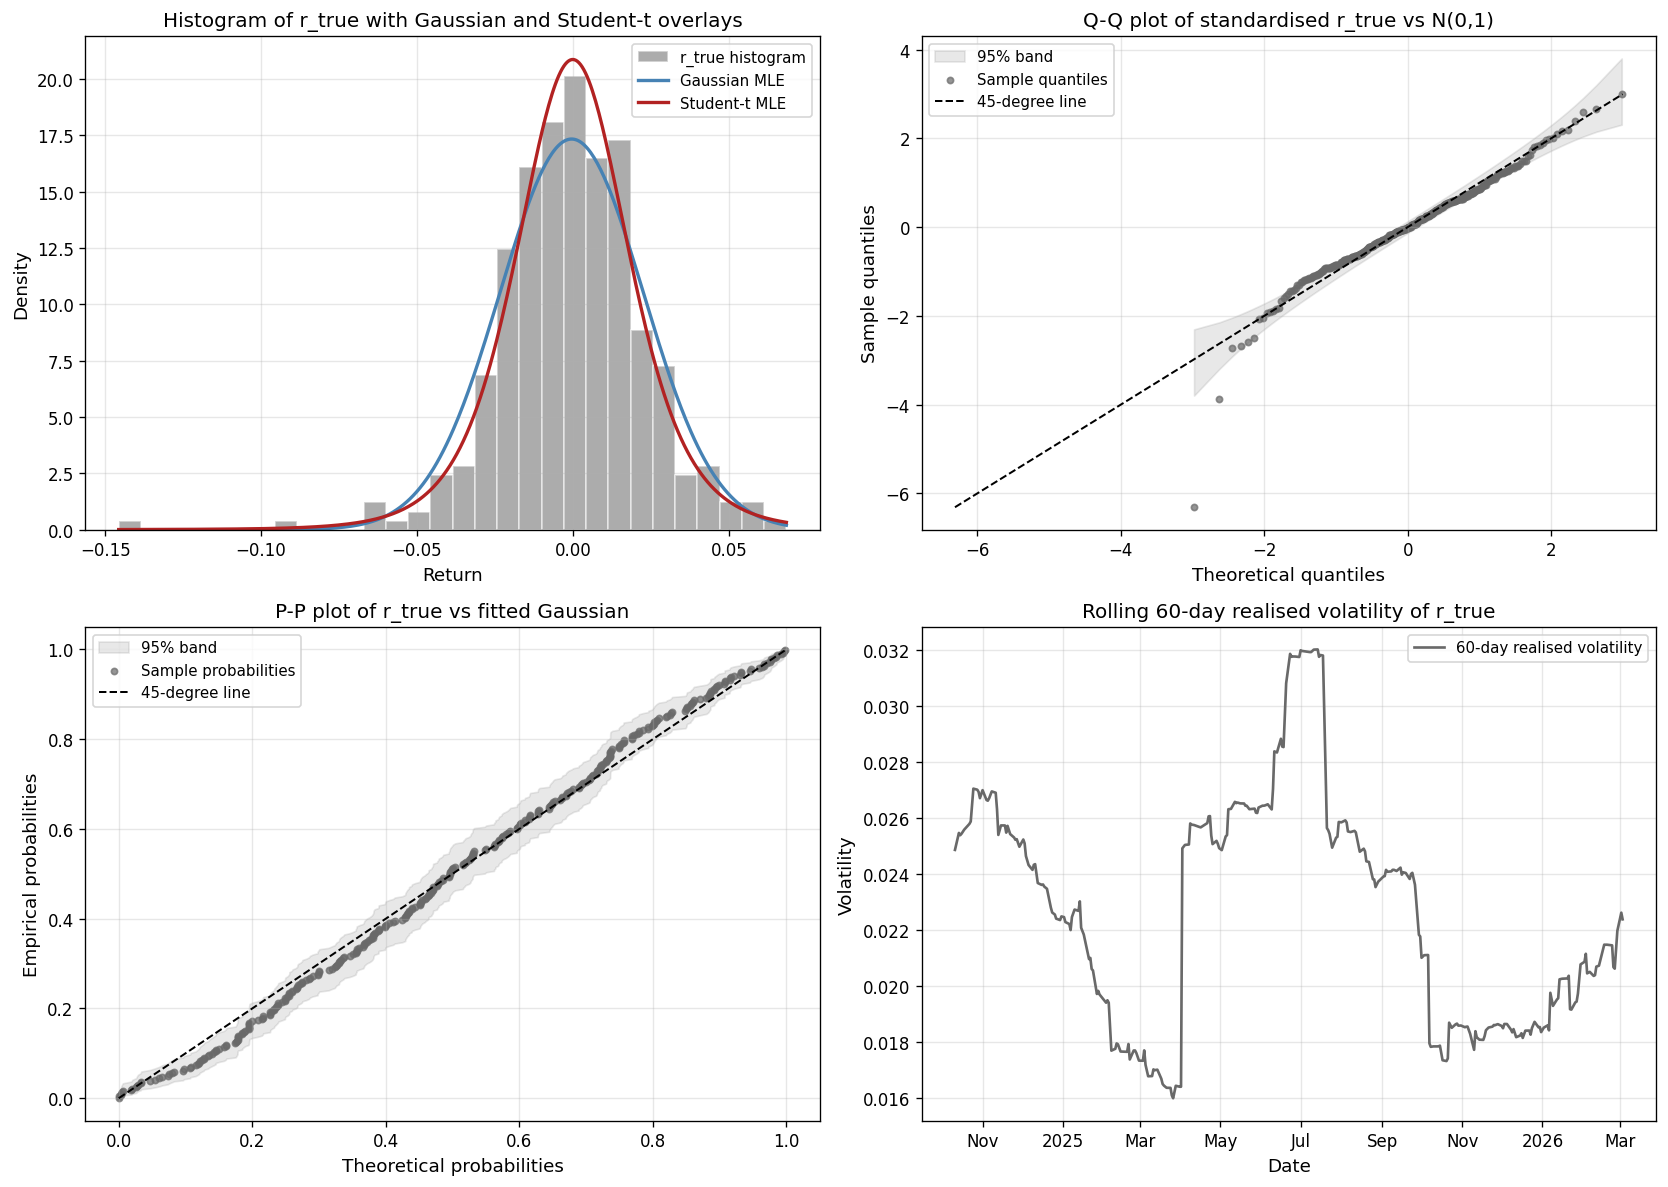

KS and AD tests for r_true against fitted benchmark distributions:


,distribution,KS statistic,KS p-value,AD statistic,AD p-value
0,Gaussian,0.0542,0.2487,1.4175,0.0010
1,Student-t,0.0257,0.9712,0.2390,0.6430


Figure 1 saved to: C:\Users\peter\Documents\GitHub\datascienceproject\notebooks\daily\return_prediction\figures\figure1_return_distribution_eda.pdf


In [5]:
r_true_summary = summary_stats(r_true)
r_true_gaussian_params = fit_gaussian_params(r_true)
r_true_student_t_params = fit_student_t_full_params(r_true)
standardised_r_true = (r_true - r_true_gaussian_params["loc"]) / r_true_gaussian_params["scale"]

summary_df = pd.DataFrame(
    [
        {
            "mean": r_true_summary["mean"],
            "std": r_true_summary["std"],
            "skewness": r_true_summary["skewness"],
            "excess_kurtosis": r_true_summary["excess_kurtosis"],
        }
    ]
)
print("Summary statistics for r_true:")
display(summary_df)

fit_df = pd.DataFrame(
    [
        {
            "distribution": "Gaussian",
            "param_1": r_true_gaussian_params["loc"],
            "param_2": r_true_gaussian_params["scale"],
            "param_3": np.nan,
        },
        {
            "distribution": "Student-t",
            "param_1": r_true_student_t_params["df"],
            "param_2": r_true_student_t_params["loc"],
            "param_3": r_true_student_t_params["scale"],
        },
    ]
)
fit_df.columns = ["distribution", "location_or_df", "scale_or_loc", "scale_if_t"]
print("MLE fits for r_true:")
display(fit_df)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

x_grid = np.linspace(np.min(r_true), np.max(r_true), 400)
axes[0, 0].hist(r_true, bins=30, density=True, alpha=0.55, color=ACTUAL_COLOR, edgecolor="white", label="r_true histogram")
axes[0, 0].plot(
    x_grid,
    stats.norm.pdf(x_grid, loc=r_true_gaussian_params["loc"], scale=r_true_gaussian_params["scale"]),
    color="steelblue",
    linewidth=2.0,
    label="Gaussian MLE",
)
axes[0, 0].plot(
    x_grid,
    stats.t.pdf(
        x_grid,
        df=r_true_student_t_params["df"],
        loc=r_true_student_t_params["loc"],
        scale=r_true_student_t_params["scale"],
    ),
    color="firebrick",
    linewidth=2.0,
    label="Student-t MLE",
)
axes[0, 0].set_xlabel("Return")
axes[0, 0].set_ylabel("Density")
axes[0, 0].set_title("Histogram of r_true with Gaussian and Student-t overlays")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

qq_plot_with_bands(
    axes[0, 1],
    standardised_r_true,
    stats.norm,
    {"loc": 0.0, "scale": 1.0},
    "Q-Q plot of standardised r_true vs N(0,1)",
    ACTUAL_COLOR,
)

pp_plot_with_bands(
    axes[1, 0],
    r_true,
    stats.norm,
    {"loc": r_true_gaussian_params["loc"], "scale": r_true_gaussian_params["scale"]},
    "P-P plot of r_true vs fitted Gaussian",
    ACTUAL_COLOR,
)

axes[1, 1].plot(DATE_INDEX, ROLLING_VOL_60.values, color=ACTUAL_COLOR, linewidth=1.6, label="60-day realised volatility")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("Volatility")
axes[1, 1].set_title("Rolling 60-day realised volatility of r_true")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
format_date_axis(axes[1, 1])

fig.tight_layout()
figure_1_path = FIGURES_DIR / "figure1_return_distribution_eda.pdf"
fig.savefig(figure_1_path, bbox_inches="tight")
plt.show()

ks_gaussian = stats.kstest(r_true, lambda x: stats.norm.cdf(x, loc=r_true_gaussian_params["loc"], scale=r_true_gaussian_params["scale"]))
ks_student_t = stats.kstest(
    r_true,
    lambda x: stats.t.cdf(x, df=r_true_student_t_params["df"], loc=r_true_student_t_params["loc"], scale=r_true_student_t_params["scale"]),
)
ad_gaussian = parametric_ad_test(r_true, fit_gaussian_params, gaussian_cdf, gaussian_sample)
ad_student_t = parametric_ad_test(r_true, fit_student_t_full_params, student_t_full_cdf, student_t_full_sample)

section1_tests = pd.DataFrame(
    [
        {
            "distribution": "Gaussian",
            "KS statistic": ks_gaussian.statistic,
            "KS p-value": ks_gaussian.pvalue,
            "AD statistic": ad_gaussian["statistic"],
            "AD p-value": ad_gaussian["pvalue"],
        },
        {
            "distribution": "Student-t",
            "KS statistic": ks_student_t.statistic,
            "KS p-value": ks_student_t.pvalue,
            "AD statistic": ad_student_t["statistic"],
            "AD p-value": ad_student_t["pvalue"],
        },
    ]
)
print("KS and AD tests for r_true against fitted benchmark distributions:")
display(section1_tests)
print(f"Figure 1 saved to: {figure_1_path}")


### Interpretation Placeholder - Section 1

- Summarise whether the test-set return distribution is materially skewed or heavy-tailed.
- Note whether the fitted Student-t visibly improves on the Gaussian benchmark in the histogram, Q-Q, P-P, and formal goodness-of-fit tests.


## Section 2 - Standardised Residuals

This section converts each model's probabilistic forecast into standardised residuals `z_t = (r_true - mu_t) / sigma_t`. Under correct Gaussian calibration the residuals should look like white noise with mean near zero, variance near one, little skewness, and no remaining dependence in either `z_t` or `|z_t|`.


Summary statistics for standardised residuals:


,model,mean,std,skewness,excess_kurtosis
0,NLL LSTM,-0.0699,0.9376,-0.8859,5.0050
1,Composite LSTM,-0.0129,0.9037,-0.1789,3.0044


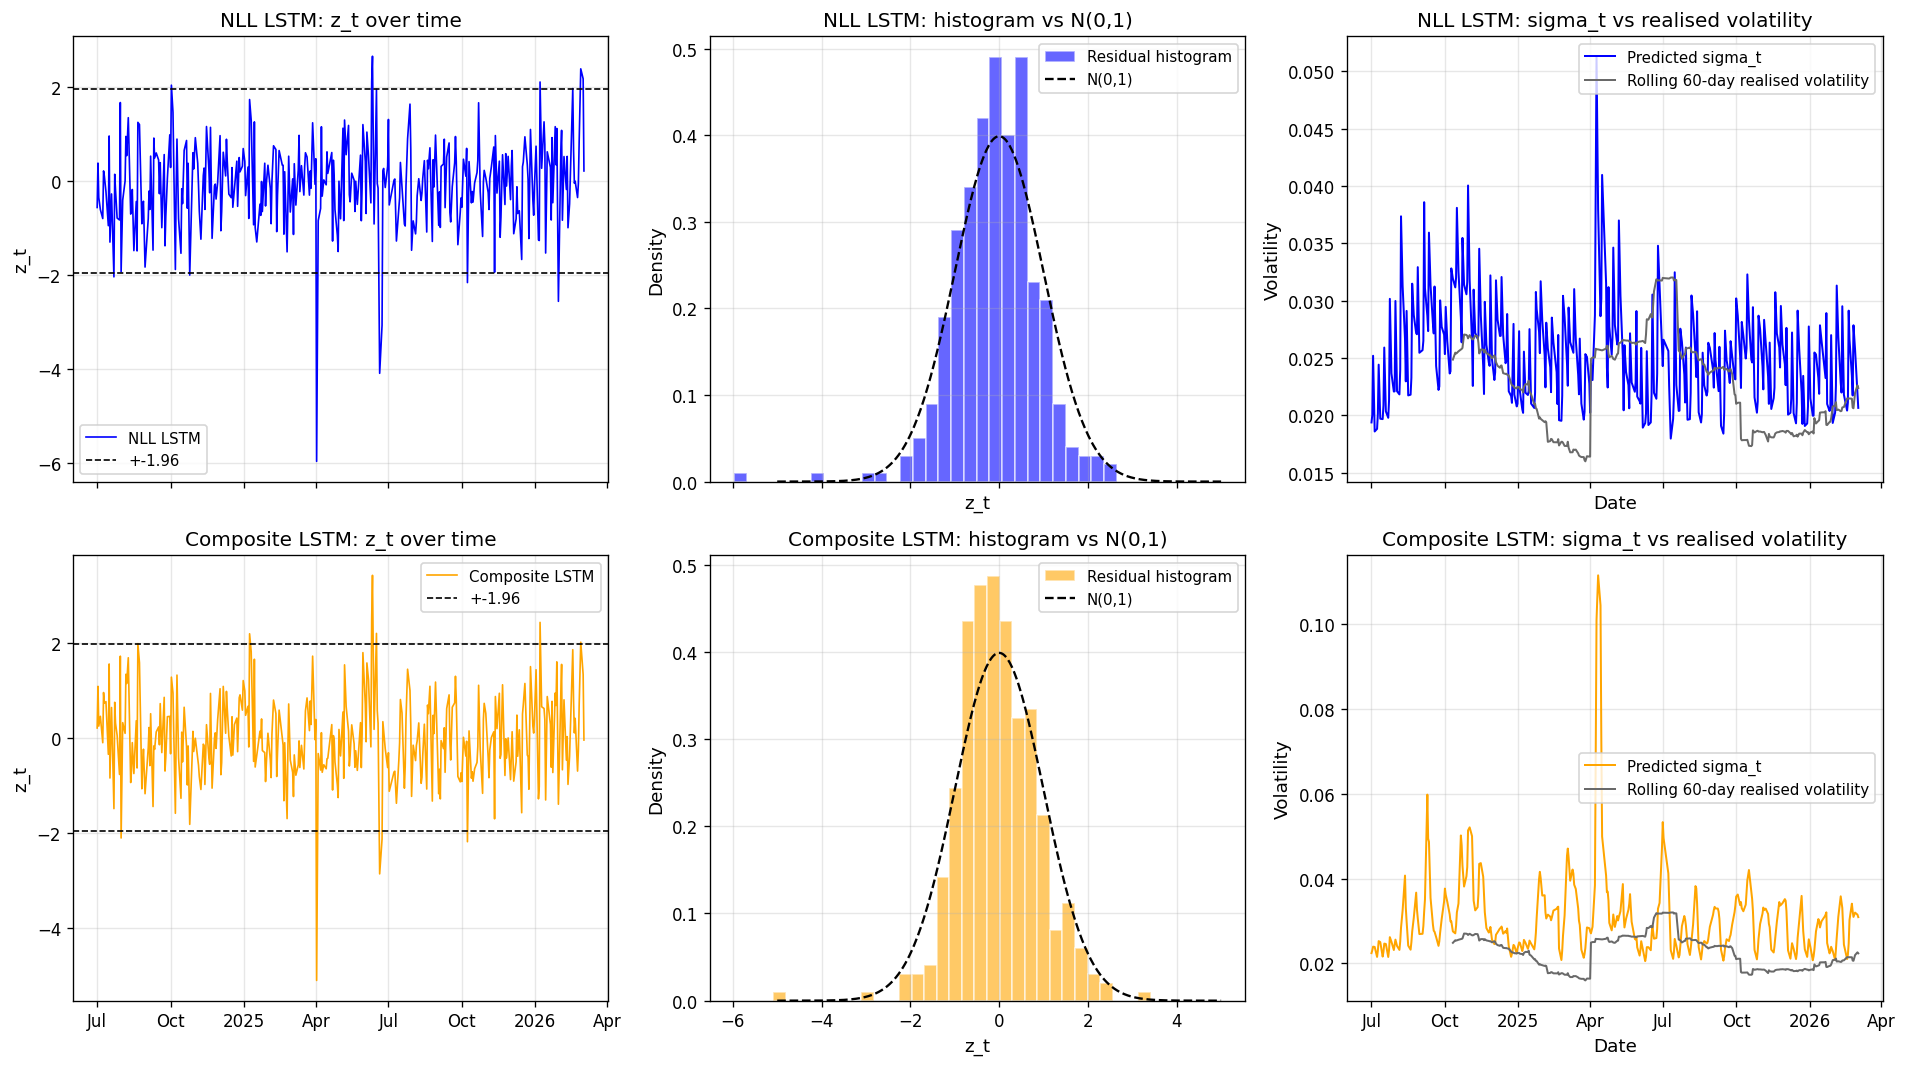

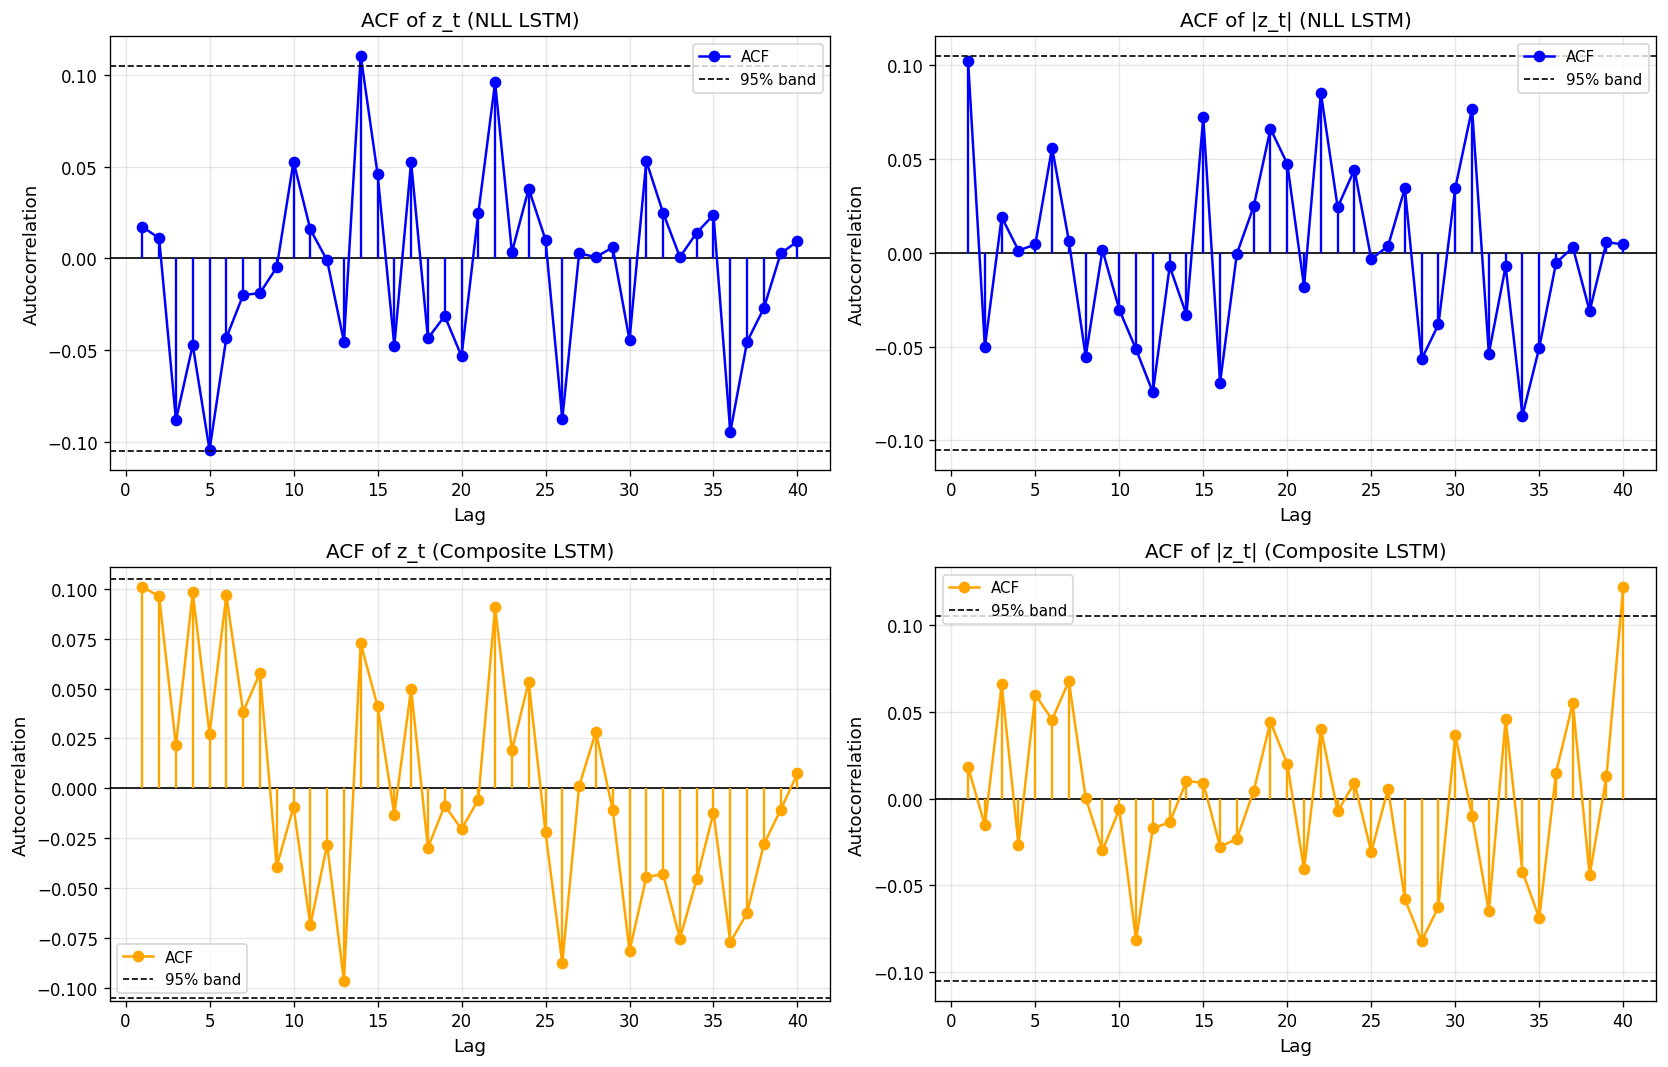

Ljung-Box tests at lag 10:


,model,series,LB statistic (lag 10),LB p-value (lag 10)
0,NLL LSTM,z_t,9.5245,0.4832
1,NLL LSTM,|z_t|,7.2372,0.7029
2,Composite LSTM,z_t,16.3544,0.0899
3,Composite LSTM,|z_t|,5.9773,0.8172


Figure 2 saved to: C:\Users\peter\Documents\GitHub\datascienceproject\notebooks\daily\return_prediction\figures\figure2_standardised_residuals.pdf
Figure 3 saved to: C:\Users\peter\Documents\GitHub\datascienceproject\notebooks\daily\return_prediction\figures\figure3_acf_grid.pdf


In [6]:
z_nll = (r_true - mu_nll) / sigma_nll
z_comp = (r_true - mu_comp) / sigma_comp

z_summary_stats = {
    "NLL LSTM": summary_stats(z_nll),
    "Composite LSTM": summary_stats(z_comp),
}

z_summary_df = pd.DataFrame(
    [
        {
            "model": label,
            "mean": stats_dict["mean"],
            "std": stats_dict["std"],
            "skewness": stats_dict["skewness"],
            "excess_kurtosis": stats_dict["excess_kurtosis"],
        }
        for label, stats_dict in z_summary_stats.items()
    ]
)
print("Summary statistics for standardised residuals:")
display(z_summary_df)

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex="col")
model_rows = [
    ("NLL LSTM", z_nll, sigma_nll, MODEL_COLORS["NLL LSTM"]),
    ("Composite LSTM", z_comp, sigma_comp, MODEL_COLORS["Composite LSTM"]),
]
for row_idx, (label, z_values, sigma_values, color) in enumerate(model_rows):
    axes[row_idx, 0].plot(DATE_INDEX, z_values, color=color, linewidth=1.0, label=label)
    axes[row_idx, 0].axhline(1.96, color=REFERENCE_COLOR, linestyle=REFERENCE_STYLE, linewidth=1.0, label="+-1.96")
    axes[row_idx, 0].axhline(-1.96, color=REFERENCE_COLOR, linestyle=REFERENCE_STYLE, linewidth=1.0)
    axes[row_idx, 0].set_ylabel("z_t")
    axes[row_idx, 0].set_title(f"{label}: z_t over time")
    axes[row_idx, 0].legend()
    axes[row_idx, 0].grid(True, alpha=0.3)
    format_date_axis(axes[row_idx, 0])

    x_grid = np.linspace(-5, 5, 400)
    axes[row_idx, 1].hist(z_values, bins=30, density=True, color=color, alpha=0.6, edgecolor="white", label="Residual histogram")
    axes[row_idx, 1].plot(x_grid, stats.norm.pdf(x_grid), color=REFERENCE_COLOR, linestyle=REFERENCE_STYLE, linewidth=1.4, label="N(0,1)")
    axes[row_idx, 1].set_xlabel("z_t")
    axes[row_idx, 1].set_ylabel("Density")
    axes[row_idx, 1].set_title(f"{label}: histogram vs N(0,1)")
    axes[row_idx, 1].legend()
    axes[row_idx, 1].grid(True, alpha=0.3)

    axes[row_idx, 2].plot(DATE_INDEX, sigma_values, color=color, linewidth=1.2, label="Predicted sigma_t")
    axes[row_idx, 2].plot(DATE_INDEX, ROLLING_VOL_60.values, color=ACTUAL_COLOR, linewidth=1.2, label="Rolling 60-day realised volatility")
    axes[row_idx, 2].set_xlabel("Date")
    axes[row_idx, 2].set_ylabel("Volatility")
    axes[row_idx, 2].set_title(f"{label}: sigma_t vs realised volatility")
    axes[row_idx, 2].legend()
    axes[row_idx, 2].grid(True, alpha=0.3)
    format_date_axis(axes[row_idx, 2])

fig.tight_layout()
figure_2_path = FIGURES_DIR / "figure2_standardised_residuals.pdf"
fig.savefig(figure_2_path, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_acf_panel(axes[0, 0], z_nll, "ACF of z_t (NLL LSTM)", MODEL_COLORS["NLL LSTM"])
plot_acf_panel(axes[0, 1], np.abs(z_nll), "ACF of |z_t| (NLL LSTM)", MODEL_COLORS["NLL LSTM"])
plot_acf_panel(axes[1, 0], z_comp, "ACF of z_t (Composite LSTM)", MODEL_COLORS["Composite LSTM"])
plot_acf_panel(axes[1, 1], np.abs(z_comp), "ACF of |z_t| (Composite LSTM)", MODEL_COLORS["Composite LSTM"])
fig.tight_layout()
figure_3_path = FIGURES_DIR / "figure3_acf_grid.pdf"
fig.savefig(figure_3_path, bbox_inches="tight")
plt.show()

lb_z_nll = ljung_box_test(z_nll, lag=10)
lb_abs_nll = ljung_box_test(np.abs(z_nll), lag=10)
lb_z_comp = ljung_box_test(z_comp, lag=10)
lb_abs_comp = ljung_box_test(np.abs(z_comp), lag=10)

lb_section2 = pd.DataFrame(
    [
        {
            "model": "NLL LSTM",
            "series": "z_t",
            "LB statistic (lag 10)": lb_z_nll[0],
            "LB p-value (lag 10)": lb_z_nll[1],
        },
        {
            "model": "NLL LSTM",
            "series": "|z_t|",
            "LB statistic (lag 10)": lb_abs_nll[0],
            "LB p-value (lag 10)": lb_abs_nll[1],
        },
        {
            "model": "Composite LSTM",
            "series": "z_t",
            "LB statistic (lag 10)": lb_z_comp[0],
            "LB p-value (lag 10)": lb_z_comp[1],
        },
        {
            "model": "Composite LSTM",
            "series": "|z_t|",
            "LB statistic (lag 10)": lb_abs_comp[0],
            "LB p-value (lag 10)": lb_abs_comp[1],
        },
    ]
)
print("Ljung-Box tests at lag 10:")
display(lb_section2)
print(f"Figure 2 saved to: {figure_2_path}")
print(f"Figure 3 saved to: {figure_3_path}")


### Interpretation Placeholder - Section 2

- Record whether the residual means and standard deviations are close to the Gaussian target values of 0 and 1.
- Note whether dependence in `|z_t|` suggests that the predicted `sigma_t` series still misses important volatility clustering.


## Section 3 - Formal Calibration Tests

This section directly tests whether each model's standardised residuals behave like draws from `N(0,1)`. The combination of KS, Anderson-Darling, Q-Q, P-P, and interval coverage diagnostics is useful because each test highlights a different failure mode: centre misfit, tail misfit, and practical interval under- or over-coverage.


KS tests of z_t against N(0,1):


,model,KS statistic,KS p-value,Conclusion at 5%
0,NLL LSTM,0.0831,0.0154,Reject H0
1,Composite LSTM,0.0628,0.1235,Fail to reject H0


Anderson-Darling tests of z_t against N(0,1):


,model,AD statistic,Critical 15%,Critical 10%,Critical 5%,Critical 2.5%,Critical 1%,Rejected 5%,Rejection level
0,NLL LSTM,1.4564,0.5600,0.6300,0.7500,0.8710,1.0330,True,Rejected at 1.0%
1,Composite LSTM,1.1601,0.5600,0.6300,0.7500,0.8710,1.0330,True,Rejected at 1.0%


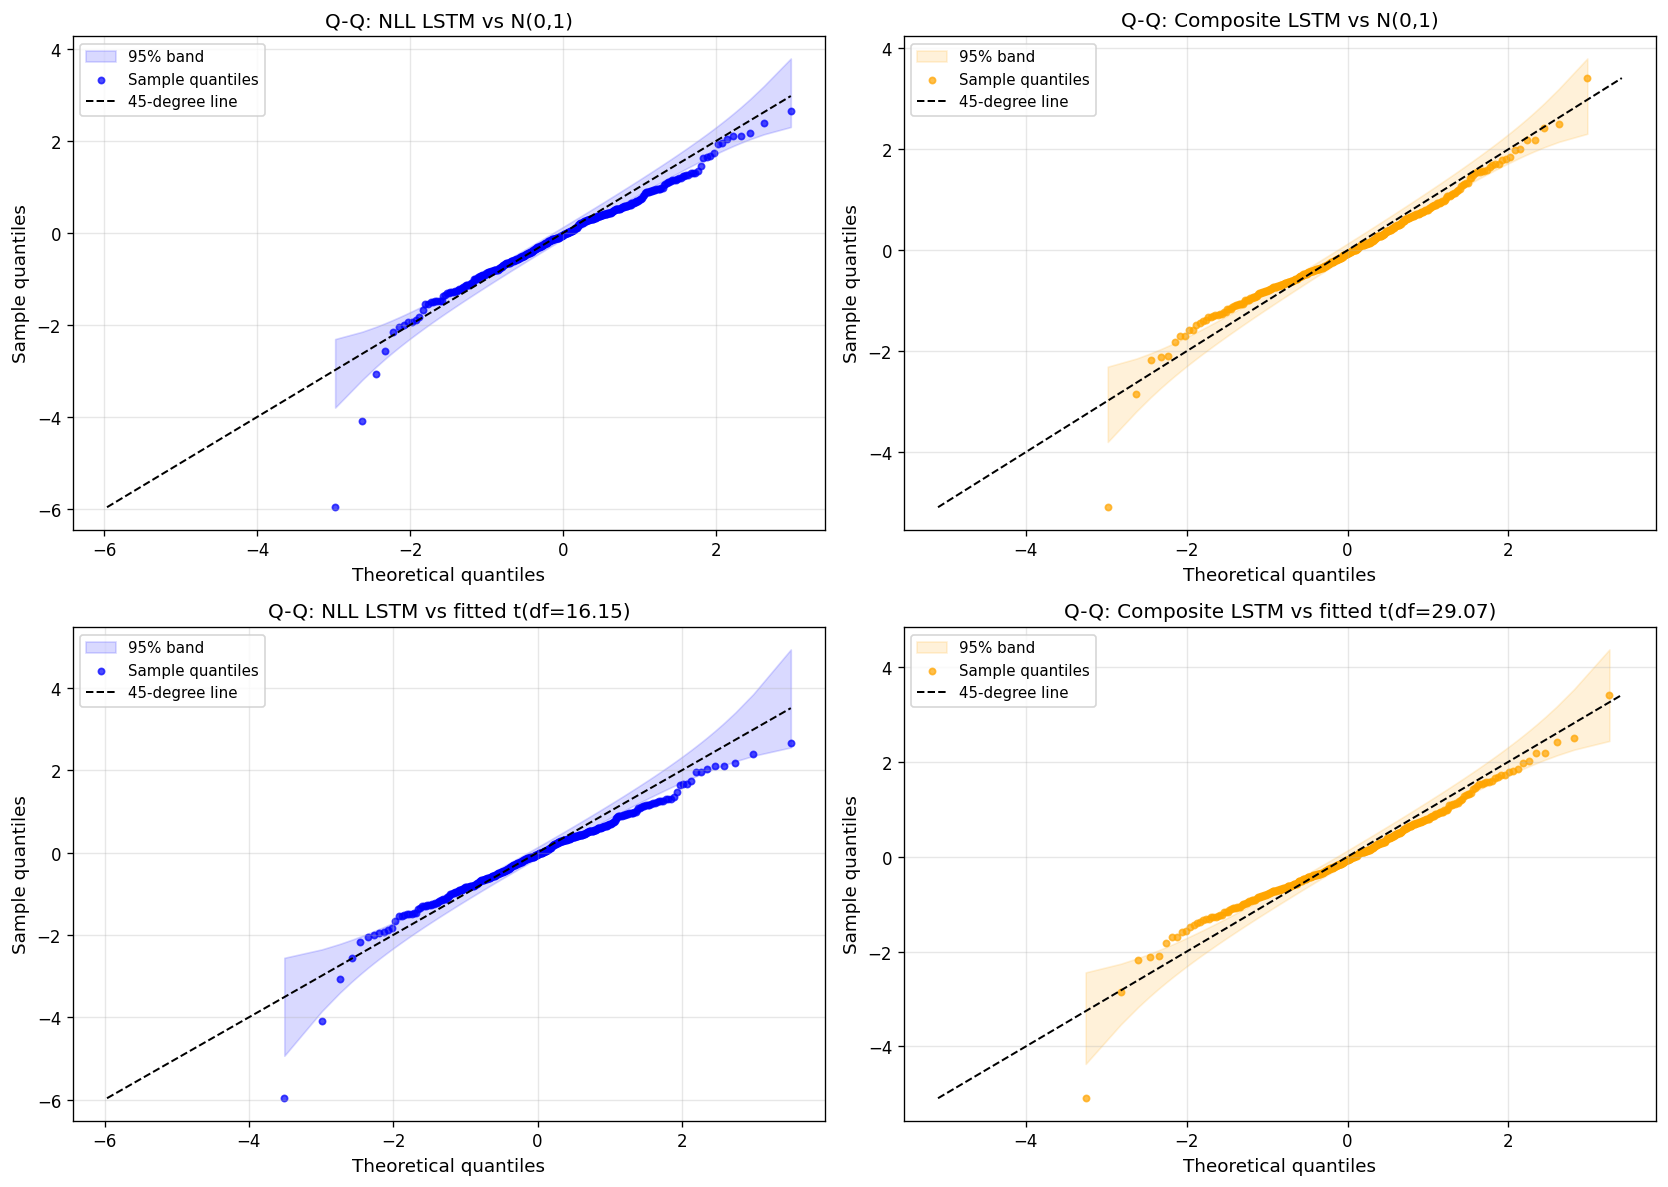

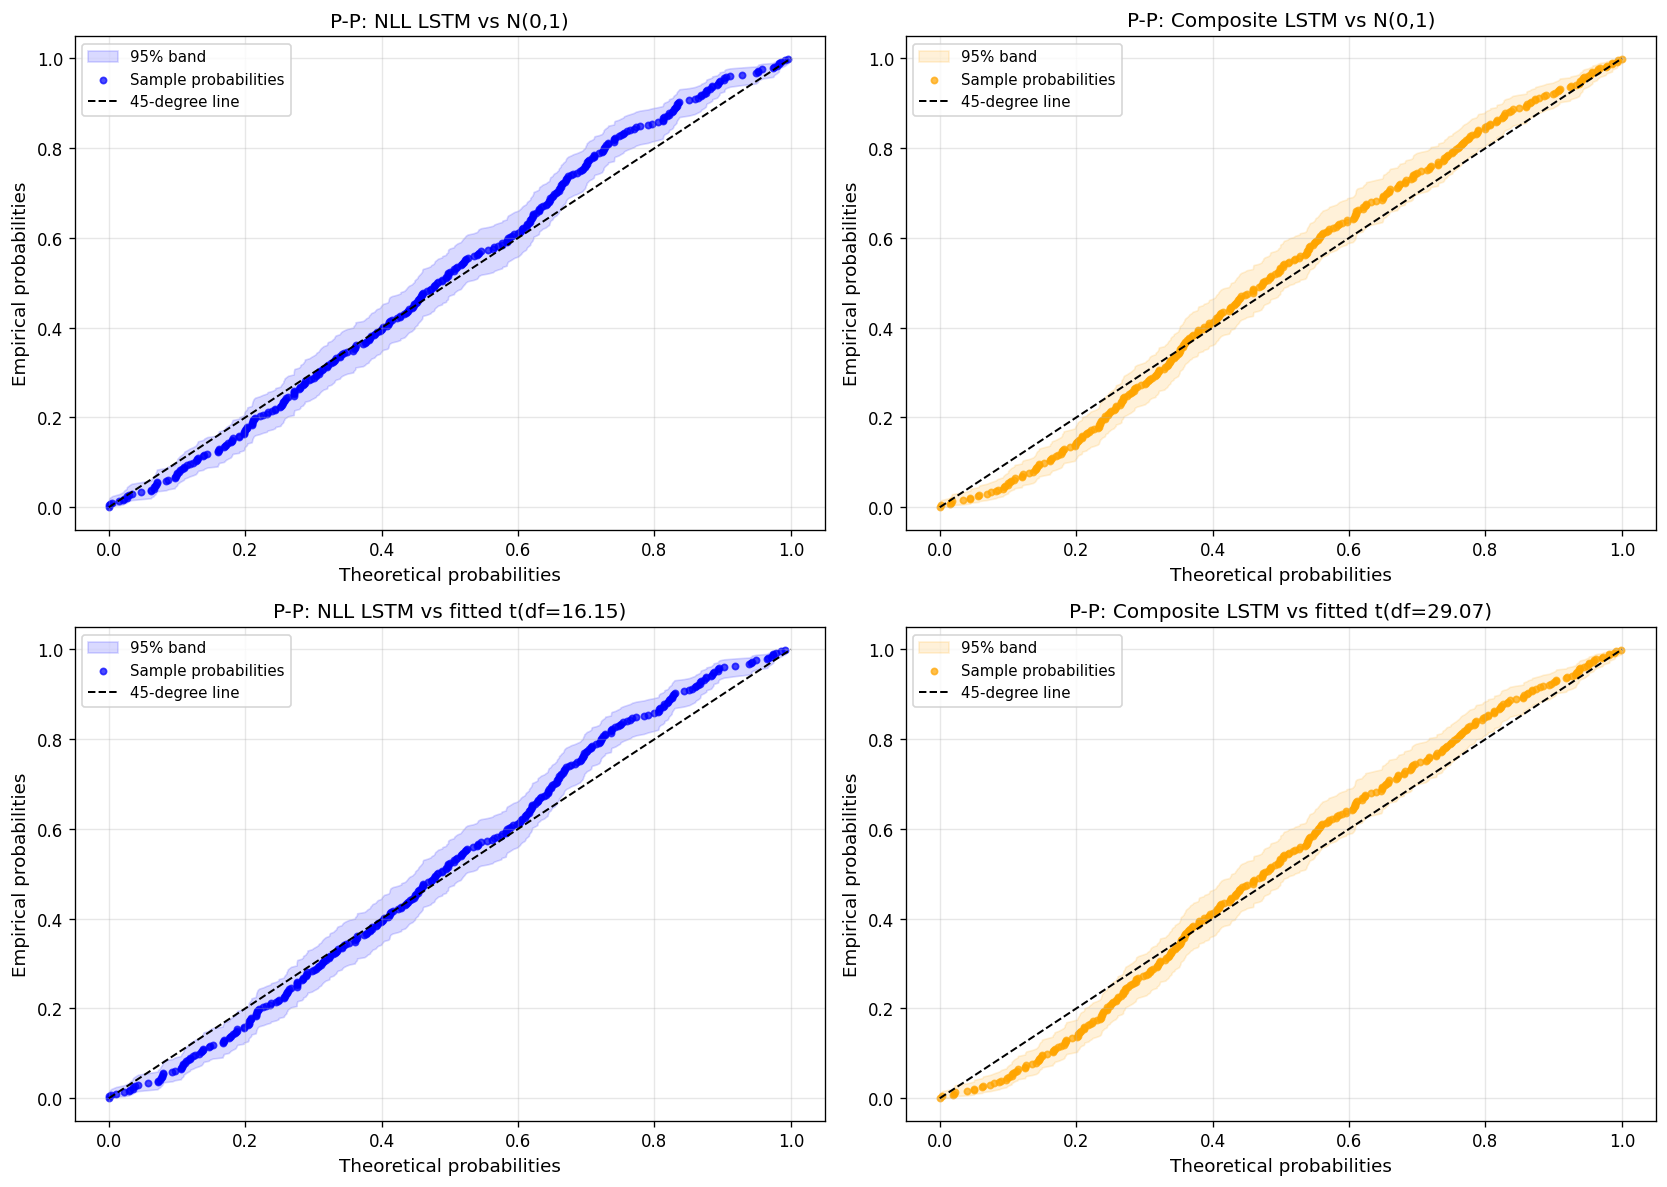

Gaussian interval coverage results for the LSTM models:


,model,alpha,nominal,empirical,difference,CI lower,CI upper,significant
0,NLL LSTM,0.5000,0.5000,0.6063,0.1063,0.4475,0.5525,True
1,NLL LSTM,0.8000,0.8000,0.8793,0.0793,0.7580,0.8420,True
2,NLL LSTM,0.9000,0.9000,0.9339,0.0339,0.8685,0.9315,True
3,NLL LSTM,0.9500,0.9500,0.9598,0.0098,0.9271,0.9729,False
4,NLL LSTM,0.9900,0.9900,0.9885,-0.0015,0.9795,1.0005,False
5,Composite LSTM,0.5000,0.5000,0.5747,0.0747,0.4475,0.5525,True
6,Composite LSTM,0.8000,0.8000,0.8736,0.0736,0.7580,0.8420,True
7,Composite LSTM,0.9000,0.9000,0.9368,0.0368,0.8685,0.9315,True
8,Composite LSTM,0.9500,0.9500,0.9655,0.0155,0.9271,0.9729,False
9,Composite LSTM,0.9900,0.9900,0.9914,0.0014,0.9795,1.0005,False


Figure 4 saved to: C:\Users\peter\Documents\GitHub\datascienceproject\notebooks\daily\return_prediction\figures\figure4_qq_grid.pdf
Figure 5 saved to: C:\Users\peter\Documents\GitHub\datascienceproject\notebooks\daily\return_prediction\figures\figure5_pp_grid.pdf


In [7]:
nu_nll = fit_standard_t_df(z_nll)
nu_comp = fit_standard_t_df(z_comp)

student_t_df_lookup = {
    "NLL LSTM": nu_nll,
    "Composite LSTM": nu_comp,
}

gaussian_diagnostics = {}
for label, z_values in [("NLL LSTM", z_nll), ("Composite LSTM", z_comp)]:
    ks_result = stats.kstest(z_values, "norm")
    anderson_result = stats.anderson(z_values, dist="norm")
    reject_5pct, critical_5pct = anderson_reject_at_level(anderson_result, level=5.0)
    gaussian_diagnostics[label] = {
        "ks_stat": float(ks_result.statistic),
        "ks_pvalue": float(ks_result.pvalue),
        "ks_conclusion_5pct": "Reject H0" if ks_result.pvalue < 0.05 else "Fail to reject H0",
        "anderson_result": anderson_result,
        "ad_stat": float(anderson_result.statistic),
        "ad_critical_5pct": critical_5pct,
        "ad_rejected_5pct": reject_5pct,
        "ad_rejection_level": anderson_rejection_level(anderson_result),
    }

ks_gaussian_df = pd.DataFrame(
    [
        {
            "model": label,
            "KS statistic": result["ks_stat"],
            "KS p-value": result["ks_pvalue"],
            "Conclusion at 5%": result["ks_conclusion_5pct"],
        }
        for label, result in gaussian_diagnostics.items()
    ]
)
print("KS tests of z_t against N(0,1):")
display(ks_gaussian_df)

ad_gaussian_df = pd.DataFrame(
    [
        {
            "model": label,
            "AD statistic": result["ad_stat"],
            "Critical 15%": result["anderson_result"].critical_values[0],
            "Critical 10%": result["anderson_result"].critical_values[1],
            "Critical 5%": result["anderson_result"].critical_values[2],
            "Critical 2.5%": result["anderson_result"].critical_values[3],
            "Critical 1%": result["anderson_result"].critical_values[4],
            "Rejected 5%": result["ad_rejected_5pct"],
            "Rejection level": result["ad_rejection_level"],
        }
        for label, result in gaussian_diagnostics.items()
    ]
)
print("Anderson-Darling tests of z_t against N(0,1):")
display(ad_gaussian_df)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
qq_plot_with_bands(axes[0, 0], z_nll, stats.norm, {"loc": 0.0, "scale": 1.0}, "Q-Q: NLL LSTM vs N(0,1)", MODEL_COLORS["NLL LSTM"])
qq_plot_with_bands(axes[0, 1], z_comp, stats.norm, {"loc": 0.0, "scale": 1.0}, "Q-Q: Composite LSTM vs N(0,1)", MODEL_COLORS["Composite LSTM"])
qq_plot_with_bands(axes[1, 0], z_nll, stats.t, {"df": nu_nll, "loc": 0.0, "scale": 1.0}, f"Q-Q: NLL LSTM vs fitted t(df={nu_nll:.2f})", MODEL_COLORS["NLL LSTM"])
qq_plot_with_bands(axes[1, 1], z_comp, stats.t, {"df": nu_comp, "loc": 0.0, "scale": 1.0}, f"Q-Q: Composite LSTM vs fitted t(df={nu_comp:.2f})", MODEL_COLORS["Composite LSTM"])
fig.tight_layout()
figure_4_path = FIGURES_DIR / "figure4_qq_grid.pdf"
fig.savefig(figure_4_path, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pp_plot_with_bands(axes[0, 0], z_nll, stats.norm, {"loc": 0.0, "scale": 1.0}, "P-P: NLL LSTM vs N(0,1)", MODEL_COLORS["NLL LSTM"])
pp_plot_with_bands(axes[0, 1], z_comp, stats.norm, {"loc": 0.0, "scale": 1.0}, "P-P: Composite LSTM vs N(0,1)", MODEL_COLORS["Composite LSTM"])
pp_plot_with_bands(axes[1, 0], z_nll, stats.t, {"df": nu_nll, "loc": 0.0, "scale": 1.0}, f"P-P: NLL LSTM vs fitted t(df={nu_nll:.2f})", MODEL_COLORS["NLL LSTM"])
pp_plot_with_bands(axes[1, 1], z_comp, stats.t, {"df": nu_comp, "loc": 0.0, "scale": 1.0}, f"P-P: Composite LSTM vs fitted t(df={nu_comp:.2f})", MODEL_COLORS["Composite LSTM"])
fig.tight_layout()
figure_5_path = FIGURES_DIR / "figure5_pp_grid.pdf"
fig.savefig(figure_5_path, bbox_inches="tight")
plt.show()

gaussian_coverage_tables = {
    "NLL LSTM": coverage_table(r_true, mu_nll, sigma_nll, COVERAGE_LEVELS, "NLL LSTM", dist_name="norm"),
    "Composite LSTM": coverage_table(r_true, mu_comp, sigma_comp, COVERAGE_LEVELS, "Composite LSTM", dist_name="norm"),
}
coverage_gaussian_all = pd.concat(list(gaussian_coverage_tables.values()), ignore_index=True)
print("Gaussian interval coverage results for the LSTM models:")
display(coverage_gaussian_all)
print(f"Figure 4 saved to: {figure_4_path}")
print(f"Figure 5 saved to: {figure_5_path}")


## Section 3b - PIT Histogram

The probability integral transform (PIT) provides a visual check of calibration.
If the predictive CDF is correctly specified, the PIT values $u_t = F_t(r_t)$ should be
uniformly distributed on $[0,1]$. Departures from uniformity indicate specific calibration failures:
a U-shape indicates underdispersion, a hump shape indicates overdispersion, and
asymmetry indicates bias.

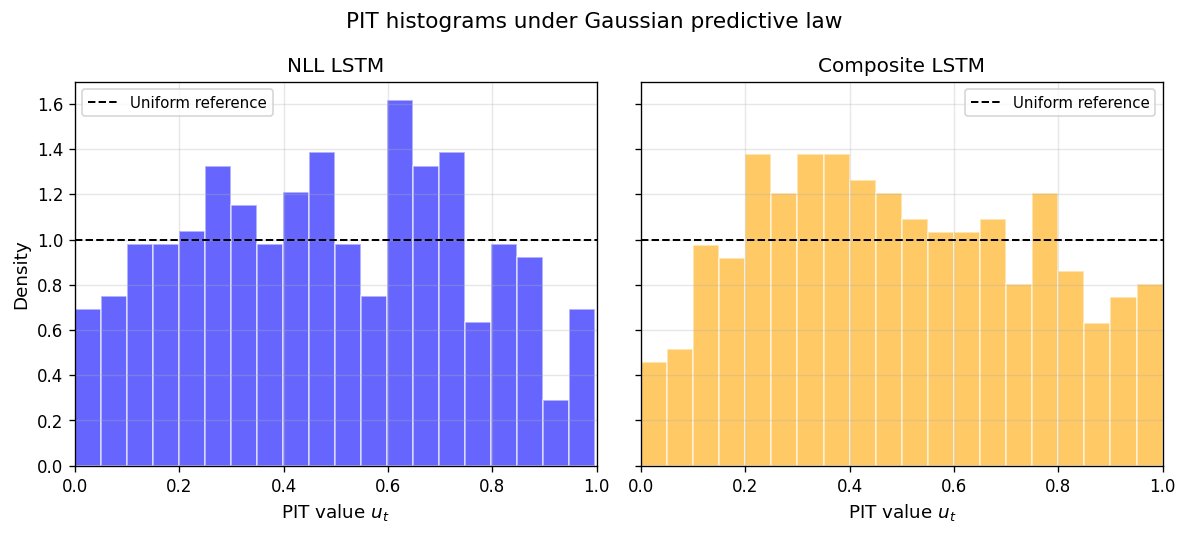

KS test of PIT values against Uniform[0,1]:


,model,KS stat,KS p-value
0,NLL LSTM,0.0831,0.0154
1,Composite LSTM,0.0628,0.1235


Figure 3b saved to: C:\Users\peter\Documents\GitHub\datascienceproject\notebooks\daily\return_prediction\figures\figure3b_pit_histograms.pdf
Note: GARCH panel omitted. Re-run this cell after Section 5 for the full 3-panel figure.


In [8]:
pit_nll = stats.norm.cdf(z_nll)
pit_comp = stats.norm.cdf(z_comp)

# GARCH residuals may not yet be computed if notebook is run sequentially
# (GARCH is fitted in Section 5). Handle gracefully.
has_garch = 'z_garch' in dir()
n_panels = 3 if has_garch else 2
if has_garch:
    pit_garch = stats.norm.cdf(z_garch)

fig, axes = plt.subplots(1, n_panels, figsize=(5*n_panels, 4.5), sharey=True)
panel_data = [
    (axes[0], pit_nll, "NLL LSTM", MODEL_COLORS["NLL LSTM"]),
    (axes[1], pit_comp, "Composite LSTM", MODEL_COLORS["Composite LSTM"]),
]
if has_garch:
    panel_data.append((axes[2], pit_garch, "GARCH(1,1)", MODEL_COLORS["GARCH(1,1)"]))

for ax, pit_values, label, color in panel_data:
    ax.hist(pit_values, bins=20, density=True, color=color, alpha=0.6, edgecolor="white")
    ax.axhline(1.0, color=REFERENCE_COLOR, linestyle=REFERENCE_STYLE, linewidth=1.2, label="Uniform reference")
    ax.set_xlabel("PIT value $u_t$")
    ax.set_title(f"{label}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0.0, 1.0)
axes[0].set_ylabel("Density")
fig.suptitle("PIT histograms under Gaussian predictive law", fontsize=13)
fig.tight_layout()
figure_3b_path = FIGURES_DIR / "figure3b_pit_histograms.pdf"
fig.savefig(figure_3b_path, bbox_inches="tight")
plt.show()

pit_ks_rows = [
    {"model": "NLL LSTM", "KS stat": stats.kstest(pit_nll, "uniform").statistic, "KS p-value": stats.kstest(pit_nll, "uniform").pvalue},
    {"model": "Composite LSTM", "KS stat": stats.kstest(pit_comp, "uniform").statistic, "KS p-value": stats.kstest(pit_comp, "uniform").pvalue},
]
if has_garch:
    pit_ks_rows.append({"model": "GARCH(1,1)", "KS stat": stats.kstest(pit_garch, "uniform").statistic, "KS p-value": stats.kstest(pit_garch, "uniform").pvalue})
pit_ks_results = pd.DataFrame(pit_ks_rows)
print("KS test of PIT values against Uniform[0,1]:")
display(pit_ks_results)
print(f"Figure 3b saved to: {figure_3b_path}")
if not has_garch:
    print("Note: GARCH panel omitted. Re-run this cell after Section 5 for the full 3-panel figure.")


### Interpretation Placeholder - Section 3

- State whether either LSTM passes the Gaussian KS or Anderson-Darling tests at conventional levels.
- Highlight whether the main calibration failures appear in the centre of the distribution, in the tails, or in interval coverage.


## Section 4 - Out-of-Sample Likelihood

Likelihood-based comparison asks how much probability mass each model assigns to the realised test-set outcomes. This matters because calibration is not only about whether residuals look approximately standard normal; it is also about whether the predicted conditional densities place sensible mass where the realised returns actually occur.


In [9]:
likelihood_results = {}
for label, mu_values, sigma_values, z_values, df_value in [
    ("NLL LSTM", mu_nll, sigma_nll, z_nll, nu_nll),
    ("Composite LSTM", mu_comp, sigma_comp, z_comp, nu_comp),
]:
    gaussian_nll, gaussian_loglik = gaussian_nll_per_observation(r_true, mu_values, sigma_values)
    student_t_nll, student_t_loglik = student_t_nll_per_observation(z_values, sigma_values, df_value)
    likelihood_results[label] = {
        "Gaussian NLL": gaussian_nll,
        "Student-t NLL": student_t_nll,
        "AIC Gaussian": -2.0 * gaussian_loglik,
        "AIC Student-t": 2.0 - 2.0 * student_t_loglik,
    }

likelihood_df = pd.DataFrame([{"Model": label, **metrics} for label, metrics in likelihood_results.items()])
print("Out-of-sample likelihood comparison (NLL per observation and AIC):")
display(likelihood_df)
print("Note: AIC Gaussian uses k=0 (mu_t and sigma_t are model outputs, not free parameters).")
print("AIC Student-t uses k=1 (nu is estimated from residuals).")


Out-of-sample likelihood comparison (NLL per observation and AIC):


,Model,Gaussian NLL,Student-t NLL,AIC Gaussian,AIC Student-t
0,NLL LSTM,-2.3319,-2.3489,-1622.9793,-1632.8170
1,Composite LSTM,-2.1953,-2.1998,-1527.9262,-1529.0412


Note: AIC Gaussian uses k=0 (mu_t and sigma_t are model outputs, not free parameters).
AIC Student-t uses k=1 (nu is estimated from residuals).


### Interpretation Placeholder - Section 4

- Note which model achieves the lower Gaussian NLL and whether that ranking changes under the Student-t extension.
- Comment on whether the Student-t penalty is justified by the improvement in fit once tail thickness is allowed to vary.


## Section 5 - GARCH(1,1) Benchmark

This section adds a classical volatility benchmark to the same calibration battery. Comparing the two LSTM models against a one-step-ahead Gaussian GARCH(1,1) forecast helps separate failures that are specific to the neural architecture from failures that are simply hard features of the underlying return process.


Fitted GARCH(1,1) parameters:


,omega,alpha,beta,persistence
0,0.0000,0.1743,0.8075,0.9818


GARCH(1,1) test battery summary:


,model,KS statistic,KS p-value,AD statistic,AD rejected 5%,LB z_t p-value,LB |z_t| p-value,Gaussian NLL
0,"GARCH(1,1)",0.0479,0.3905,1.9676,True,0.6062,0.6724,-2.3150


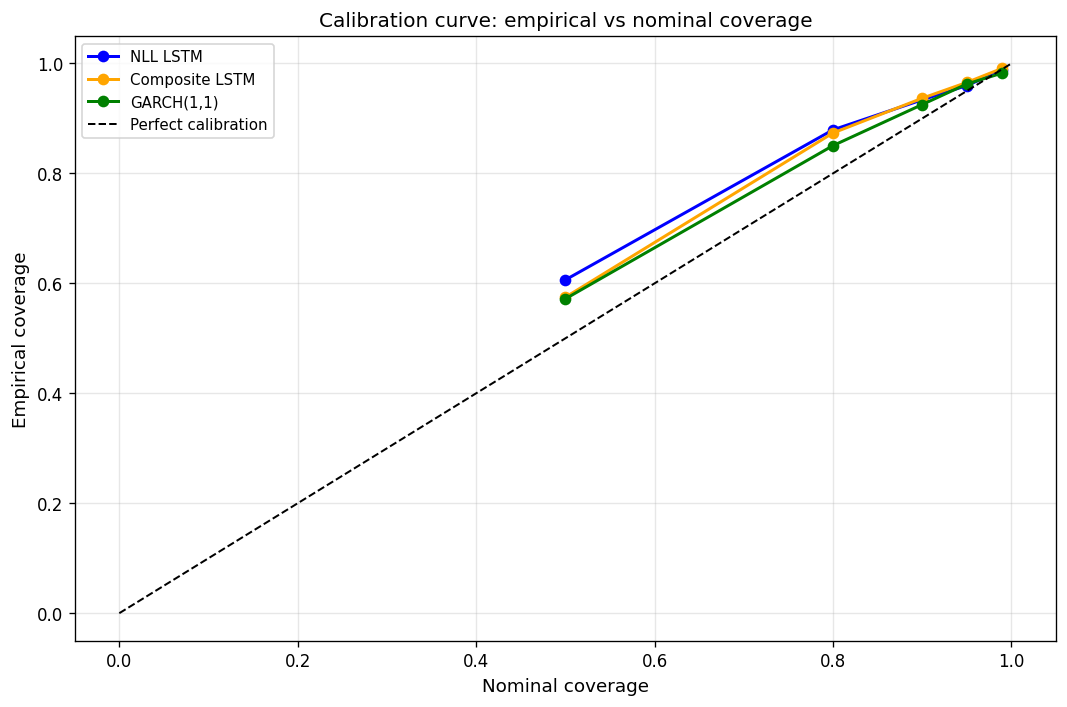

Updated likelihood comparison with GARCH Student-t:


,Model,Gaussian NLL,Student-t NLL,AIC Gaussian,AIC Student-t
0,NLL LSTM,-2.3319,-2.3489,-1622.9793,-1632.8170
1,Composite LSTM,-2.1953,-2.1998,-1527.9262,-1529.0412
2,"GARCH(1,1)",-2.3150,-2.3625,-1611.2612,-1642.2656


GARCH(1,1) Student-t fitted df: 11.64
GARCH(1,1) Gaussian NLL: -2.3150, Student-t NLL: -2.3625
Gaussian coverage results including GARCH(1,1):


,model,alpha,nominal,empirical,difference,CI lower,CI upper,significant
0,NLL LSTM,0.5000,0.5000,0.6063,0.1063,0.4475,0.5525,True
1,NLL LSTM,0.8000,0.8000,0.8793,0.0793,0.7580,0.8420,True
2,NLL LSTM,0.9000,0.9000,0.9339,0.0339,0.8685,0.9315,True
3,NLL LSTM,0.9500,0.9500,0.9598,0.0098,0.9271,0.9729,False
4,NLL LSTM,0.9900,0.9900,0.9885,-0.0015,0.9795,1.0005,False
5,Composite LSTM,0.5000,0.5000,0.5747,0.0747,0.4475,0.5525,True
6,Composite LSTM,0.8000,0.8000,0.8736,0.0736,0.7580,0.8420,True
7,Composite LSTM,0.9000,0.9000,0.9368,0.0368,0.8685,0.9315,True
8,Composite LSTM,0.9500,0.9500,0.9655,0.0155,0.9271,0.9729,False
9,Composite LSTM,0.9900,0.9900,0.9914,0.0014,0.9795,1.0005,False


Figure 6 saved to: C:\Users\peter\Documents\GitHub\datascienceproject\notebooks\daily\return_prediction\figures\figure6_coverage_calibration_curve.pdf


In [10]:
garch_model = arch_model(train_returns, mean="Zero", vol="GARCH", p=1, q=1, dist="normal", rescale=False)
garch_result = garch_model.fit(disp="off")

omega = float(garch_result.params["omega"])
alpha = float(garch_result.params["alpha[1]"])
beta = float(garch_result.params["beta[1]"])
persistence = alpha + beta

initial_sigma2 = float(np.asarray(garch_result.conditional_volatility)[-1] ** 2)
bridge_returns = np.concatenate([val_returns, r_true])
sigma_bridge = recursive_garch_sigma(omega, alpha, beta, train_returns[-1], initial_sigma2, bridge_returns)
sigma_garch = np.clip(sigma_bridge[-len(r_true):], 1e-8, None)
mu_garch = np.zeros_like(r_true)
z_garch = r_true / sigma_garch

garch_params_df = pd.DataFrame(
    [{"omega": omega, "alpha": alpha, "beta": beta, "persistence": persistence}]
)
print("Fitted GARCH(1,1) parameters:")
display(garch_params_df)

garch_ks = stats.kstest(z_garch, "norm")
garch_anderson = stats.anderson(z_garch, dist="norm")
garch_reject_5pct, garch_critical_5pct = anderson_reject_at_level(garch_anderson, level=5.0)
garch_lb_z = ljung_box_test(z_garch, lag=10)
garch_lb_abs = ljung_box_test(np.abs(z_garch), lag=10)
garch_coverage_table = coverage_table(r_true, mu_garch, sigma_garch, COVERAGE_LEVELS, "GARCH(1,1)", dist_name="norm")
garch_gaussian_nll, garch_gaussian_loglik = gaussian_nll_per_observation(r_true, mu_garch, sigma_garch)

likelihood_results["GARCH(1,1)"] = {
    "Gaussian NLL": garch_gaussian_nll,
    "Student-t NLL": np.nan,
    "AIC Gaussian": -2.0 * garch_gaussian_loglik,
    "AIC Student-t": np.nan,
}

gaussian_diagnostics["GARCH(1,1)"] = {
    "ks_stat": float(garch_ks.statistic),
    "ks_pvalue": float(garch_ks.pvalue),
    "ks_conclusion_5pct": "Reject H0" if garch_ks.pvalue < 0.05 else "Fail to reject H0",
    "anderson_result": garch_anderson,
    "ad_stat": float(garch_anderson.statistic),
    "ad_critical_5pct": garch_critical_5pct,
    "ad_rejected_5pct": garch_reject_5pct,
    "ad_rejection_level": anderson_rejection_level(garch_anderson),
}
z_summary_stats["GARCH(1,1)"] = summary_stats(z_garch)

section5_battery = pd.DataFrame(
    [
        {
            "model": "GARCH(1,1)",
            "KS statistic": gaussian_diagnostics["GARCH(1,1)"]["ks_stat"],
            "KS p-value": gaussian_diagnostics["GARCH(1,1)"]["ks_pvalue"],
            "AD statistic": gaussian_diagnostics["GARCH(1,1)"]["ad_stat"],
            "AD rejected 5%": gaussian_diagnostics["GARCH(1,1)"]["ad_rejected_5pct"],
            "LB z_t p-value": garch_lb_z[1],
            "LB |z_t| p-value": garch_lb_abs[1],
            "Gaussian NLL": garch_gaussian_nll,
        }
    ]
)
print("GARCH(1,1) test battery summary:")
display(section5_battery)

coverage_gaussian_with_garch = pd.concat(
    [gaussian_coverage_tables["NLL LSTM"], gaussian_coverage_tables["Composite LSTM"], garch_coverage_table],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(9, 6))
for label, color in [
    ("NLL LSTM", MODEL_COLORS["NLL LSTM"]),
    ("Composite LSTM", MODEL_COLORS["Composite LSTM"]),
    ("GARCH(1,1)", MODEL_COLORS["GARCH(1,1)"]),
]:
    subset = coverage_gaussian_with_garch[coverage_gaussian_with_garch["model"] == label]
    ax.plot(subset["nominal"], subset["empirical"], marker="o", linewidth=1.8, color=color, label=label)
ax.plot([0.0, 1.0], [0.0, 1.0], color=REFERENCE_COLOR, linestyle=REFERENCE_STYLE, linewidth=1.2, label="Perfect calibration")
ax.set_xlabel("Nominal coverage")
ax.set_ylabel("Empirical coverage")
ax.set_title("Calibration curve: empirical vs nominal coverage")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
figure_6_path = FIGURES_DIR / "figure6_coverage_calibration_curve.pdf"
fig.savefig(figure_6_path, bbox_inches="tight")
plt.show()

nu_garch = fit_standard_t_df(z_garch)
student_t_df_lookup["GARCH(1,1)"] = nu_garch
garch_student_t_nll, garch_student_t_loglik = student_t_nll_per_observation(z_garch, sigma_garch, nu_garch)

likelihood_results["GARCH(1,1)"]["Student-t NLL"] = garch_student_t_nll
likelihood_results["GARCH(1,1)"]["AIC Student-t"] = 2.0 - 2.0 * garch_student_t_loglik

# Re-display the full likelihood table now that GARCH is complete
updated_likelihood_df = pd.DataFrame([{"Model": label, **metrics} for label, metrics in likelihood_results.items()])
print("Updated likelihood comparison with GARCH Student-t:")
display(updated_likelihood_df)

print(f"GARCH(1,1) Student-t fitted df: {nu_garch:.2f}")
print(f"GARCH(1,1) Gaussian NLL: {garch_gaussian_nll:.4f}, Student-t NLL: {garch_student_t_nll:.4f}")

print("Gaussian coverage results including GARCH(1,1):")
display(coverage_gaussian_with_garch)
print(f"Figure 6 saved to: {figure_6_path}")


### Interpretation Placeholder - Section 5

- Compare the GARCH persistence estimate with the LSTM volatility behaviour observed earlier.
- Record whether GARCH improves the volatility-calibration diagnostics or whether the same tail and coverage problems persist under a classical benchmark.


## Section 6 - Student-t Extension

This section relaxes the Gaussian residual assumption for the two LSTM models by fitting a fixed-location, fixed-scale Student-t distribution to each standardised residual series. It matters because heavy-tailed residuals can look badly calibrated under a Gaussian benchmark even when the conditional mean and volatility dynamics are broadly sensible.


Fitted Student-t degrees of freedom for z_t:


,model,fitted nu
0,NLL LSTM,16.1456
1,Composite LSTM,29.0734
2,"GARCH(1,1)",11.6355


Student-t calibration tests compared with the Gaussian baseline:


,model,Gaussian KS statistic,Gaussian KS p-value,Student-t KS statistic,Student-t KS p-value,Gaussian AD statistic,Student-t AD statistic,Student-t AD p-value,Improved vs Gaussian KS,Improved vs Gaussian AD
0,NLL LSTM,0.0831,0.0154,0.0877,0.0089,1.4564,3.9805,0.0092,False,False
1,Composite LSTM,0.0628,0.1235,0.0662,0.0902,1.1601,3.6374,0.0131,False,False
2,"GARCH(1,1)",0.0479,0.3905,0.0561,0.2151,1.9676,2.6949,0.0352,False,False


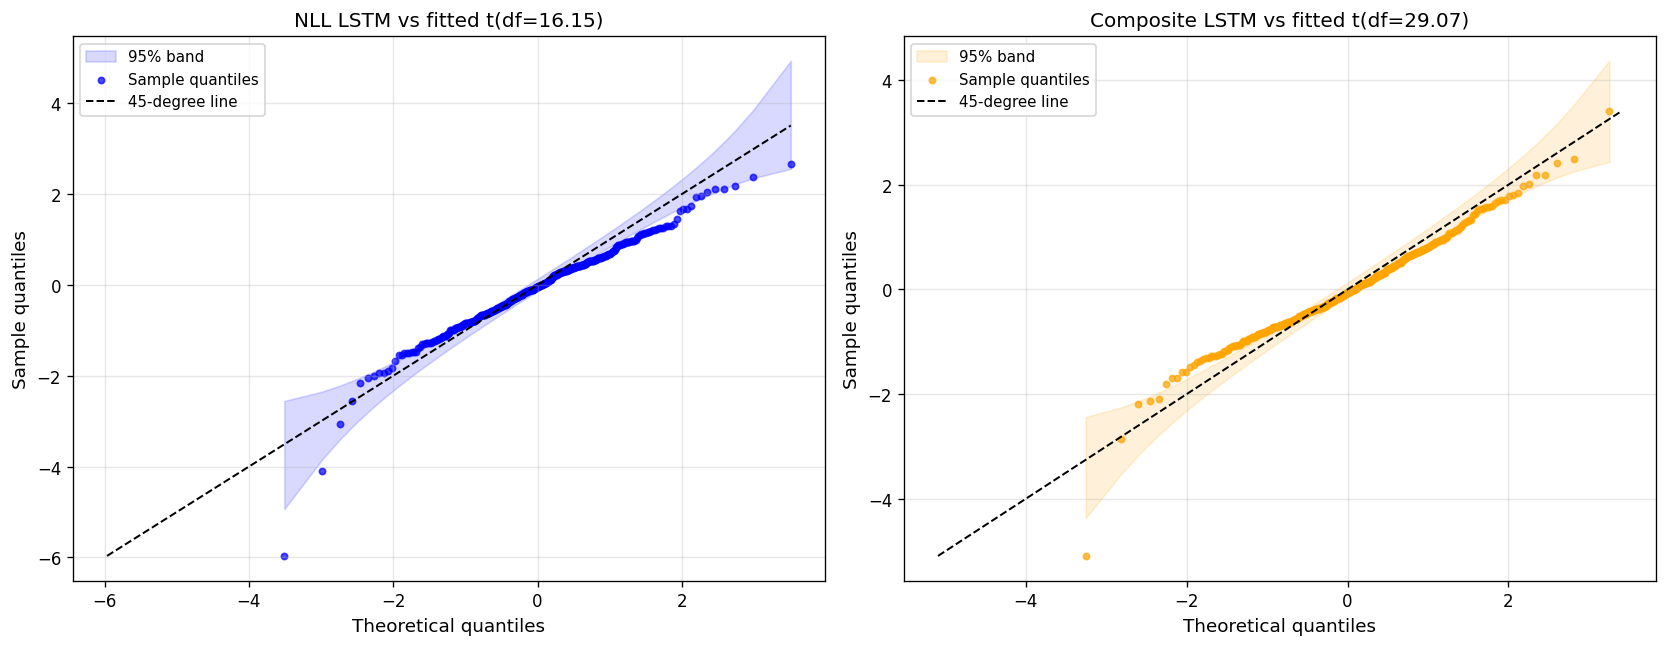

Student-t coverage results for the LSTM models:


,model,alpha,nominal,empirical,difference,CI lower,CI upper,significant
0,NLL LSTM,0.5000,0.5000,0.6121,0.1121,0.4475,0.5525,True
1,NLL LSTM,0.8000,0.8000,0.8966,0.0966,0.7580,0.8420,True
2,NLL LSTM,0.9000,0.9000,0.9454,0.0454,0.8685,0.9315,True
3,NLL LSTM,0.9500,0.9500,0.9770,0.0270,0.9271,0.9729,True
4,NLL LSTM,0.9900,0.9900,0.9914,0.0014,0.9795,1.0005,False
5,Composite LSTM,0.5000,0.5000,0.5833,0.0833,0.4475,0.5525,True
6,Composite LSTM,0.8000,0.8000,0.8793,0.0793,0.7580,0.8420,True
7,Composite LSTM,0.9000,0.9000,0.9454,0.0454,0.8685,0.9315,True
8,Composite LSTM,0.9500,0.9500,0.9713,0.0213,0.9271,0.9729,False
9,Composite LSTM,0.9900,0.9900,0.9914,0.0014,0.9795,1.0005,False


Figure 7 saved to: C:\Users\peter\Documents\GitHub\datascienceproject\notebooks\daily\return_prediction\figures\figure7_student_t_qq_plots.pdf


In [11]:
student_t_diagnostics = {}
for label, z_values, df_value in [
    ("NLL LSTM", z_nll, nu_nll),
    ("Composite LSTM", z_comp, nu_comp),
    ("GARCH(1,1)", z_garch, nu_garch),
]:
    ks_result = stats.kstest(z_values, lambda x, df=df_value: stats.t.cdf(x, df=df, loc=0.0, scale=1.0))
    ad_result = parametric_ad_test(z_values, fit_standard_t_params, student_t_standard_cdf, student_t_standard_sample)
    student_t_diagnostics[label] = {
        "df": df_value,
        "ks_stat": float(ks_result.statistic),
        "ks_pvalue": float(ks_result.pvalue),
        "ad_stat": float(ad_result["statistic"]),
        "ad_pvalue": float(ad_result["pvalue"]),
        "ad_rejected_5pct": bool(ad_result["pvalue"] < 0.05),
    }

student_t_fit_df = pd.DataFrame(
    [{"model": label, "fitted nu": result["df"]} for label, result in student_t_diagnostics.items()]
)
print("Fitted Student-t degrees of freedom for z_t:")
display(student_t_fit_df)

student_t_tests_df = pd.DataFrame(
    [
        {
            "model": label,
            "Gaussian KS statistic": gaussian_diagnostics[label]["ks_stat"],
            "Gaussian KS p-value": gaussian_diagnostics[label]["ks_pvalue"],
            "Student-t KS statistic": result["ks_stat"],
            "Student-t KS p-value": result["ks_pvalue"],
            "Gaussian AD statistic": gaussian_diagnostics[label]["ad_stat"],
            "Student-t AD statistic": result["ad_stat"],
            "Student-t AD p-value": result["ad_pvalue"],
            "Improved vs Gaussian KS": result["ks_stat"] < gaussian_diagnostics[label]["ks_stat"],
            "Improved vs Gaussian AD": result["ad_stat"] < gaussian_diagnostics[label]["ad_stat"],
        }
        for label, result in student_t_diagnostics.items()
    ]
)
print("Student-t calibration tests compared with the Gaussian baseline:")
display(student_t_tests_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
qq_plot_with_bands(axes[0], z_nll, stats.t, {"df": nu_nll, "loc": 0.0, "scale": 1.0}, f"NLL LSTM vs fitted t(df={nu_nll:.2f})", MODEL_COLORS["NLL LSTM"])
qq_plot_with_bands(axes[1], z_comp, stats.t, {"df": nu_comp, "loc": 0.0, "scale": 1.0}, f"Composite LSTM vs fitted t(df={nu_comp:.2f})", MODEL_COLORS["Composite LSTM"])
fig.tight_layout()
figure_7_path = FIGURES_DIR / "figure7_student_t_qq_plots.pdf"
fig.savefig(figure_7_path, bbox_inches="tight")
plt.show()

student_t_coverage_tables = {
    "NLL LSTM": coverage_table(r_true, mu_nll, sigma_nll, COVERAGE_LEVELS, "NLL LSTM", dist_name="t", df_value=nu_nll),
    "Composite LSTM": coverage_table(r_true, mu_comp, sigma_comp, COVERAGE_LEVELS, "Composite LSTM", dist_name="t", df_value=nu_comp),
    "GARCH(1,1)": coverage_table(r_true, mu_garch, sigma_garch, COVERAGE_LEVELS, "GARCH(1,1)", dist_name="t", df_value=nu_garch),
}
student_t_coverage_all = pd.concat(list(student_t_coverage_tables.values()), ignore_index=True)
print("Student-t coverage results for the LSTM models:")
display(student_t_coverage_all)
print(f"Figure 7 saved to: {figure_7_path}")


### Interpretation Placeholder - Section 6

- Note whether the fitted Student-t degrees of freedom are low enough to indicate materially heavy-tailed residuals.
- Record whether allowing Student-t tails improves the Q-Q plots, formal tests, and empirical coverage relative to the Gaussian benchmark.


## Section 7 - Summary Table

This section condenses the main calibration outputs into a single table suitable for reporting. The goal is to make the trade-off between central calibration, tail calibration, interval coverage, and likelihood performance easy to compare across Gaussian and Student-t specifications.


In [12]:
summary_rows = [
    {
        "Model": "NLL LSTM (Gaussian)",
        "z mean": z_summary_stats["NLL LSTM"]["mean"],
        "z std": z_summary_stats["NLL LSTM"]["std"],
        "z excess kurtosis": z_summary_stats["NLL LSTM"]["excess_kurtosis"],
        "KS stat": gaussian_diagnostics["NLL LSTM"]["ks_stat"],
        "KS p-val": gaussian_diagnostics["NLL LSTM"]["ks_pvalue"],
        "AD stat": gaussian_diagnostics["NLL LSTM"]["ad_stat"],
        "AD rejected 5%": gaussian_diagnostics["NLL LSTM"]["ad_rejected_5pct"],
        "95% empirical coverage": float(gaussian_coverage_tables["NLL LSTM"].set_index("alpha").loc[0.95, "empirical"]),
        "Gaussian NLL": likelihood_results["NLL LSTM"]["Gaussian NLL"],
        "Student-t NLL": likelihood_results["NLL LSTM"]["Student-t NLL"],
        "LB |z_t| p-val (lag 10)": float(lb_section2[(lb_section2["model"] == "NLL LSTM") & (lb_section2["series"] == "|z_t|")]["LB p-value (lag 10)"].iloc[0]),
    },
    {
        "Model": "NLL LSTM (Student-t)",
        "z mean": z_summary_stats["NLL LSTM"]["mean"],
        "z std": z_summary_stats["NLL LSTM"]["std"],
        "z excess kurtosis": z_summary_stats["NLL LSTM"]["excess_kurtosis"],
        "KS stat": student_t_diagnostics["NLL LSTM"]["ks_stat"],
        "KS p-val": student_t_diagnostics["NLL LSTM"]["ks_pvalue"],
        "AD stat": student_t_diagnostics["NLL LSTM"]["ad_stat"],
        "AD rejected 5%": student_t_diagnostics["NLL LSTM"]["ad_rejected_5pct"],
        "95% empirical coverage": float(student_t_coverage_tables["NLL LSTM"].set_index("alpha").loc[0.95, "empirical"]),
        "Gaussian NLL": likelihood_results["NLL LSTM"]["Gaussian NLL"],
        "Student-t NLL": likelihood_results["NLL LSTM"]["Student-t NLL"],
        "LB |z_t| p-val (lag 10)": float(lb_section2[(lb_section2["model"] == "NLL LSTM") & (lb_section2["series"] == "|z_t|")]["LB p-value (lag 10)"].iloc[0]),
    },
    {
        "Model": "Composite LSTM (Gaussian)",
        "z mean": z_summary_stats["Composite LSTM"]["mean"],
        "z std": z_summary_stats["Composite LSTM"]["std"],
        "z excess kurtosis": z_summary_stats["Composite LSTM"]["excess_kurtosis"],
        "KS stat": gaussian_diagnostics["Composite LSTM"]["ks_stat"],
        "KS p-val": gaussian_diagnostics["Composite LSTM"]["ks_pvalue"],
        "AD stat": gaussian_diagnostics["Composite LSTM"]["ad_stat"],
        "AD rejected 5%": gaussian_diagnostics["Composite LSTM"]["ad_rejected_5pct"],
        "95% empirical coverage": float(gaussian_coverage_tables["Composite LSTM"].set_index("alpha").loc[0.95, "empirical"]),
        "Gaussian NLL": likelihood_results["Composite LSTM"]["Gaussian NLL"],
        "Student-t NLL": likelihood_results["Composite LSTM"]["Student-t NLL"],
        "LB |z_t| p-val (lag 10)": float(lb_section2[(lb_section2["model"] == "Composite LSTM") & (lb_section2["series"] == "|z_t|")]["LB p-value (lag 10)"].iloc[0]),
    },
    {
        "Model": "Composite LSTM (Student-t)",
        "z mean": z_summary_stats["Composite LSTM"]["mean"],
        "z std": z_summary_stats["Composite LSTM"]["std"],
        "z excess kurtosis": z_summary_stats["Composite LSTM"]["excess_kurtosis"],
        "KS stat": student_t_diagnostics["Composite LSTM"]["ks_stat"],
        "KS p-val": student_t_diagnostics["Composite LSTM"]["ks_pvalue"],
        "AD stat": student_t_diagnostics["Composite LSTM"]["ad_stat"],
        "AD rejected 5%": student_t_diagnostics["Composite LSTM"]["ad_rejected_5pct"],
        "95% empirical coverage": float(student_t_coverage_tables["Composite LSTM"].set_index("alpha").loc[0.95, "empirical"]),
        "Gaussian NLL": likelihood_results["Composite LSTM"]["Gaussian NLL"],
        "Student-t NLL": likelihood_results["Composite LSTM"]["Student-t NLL"],
        "LB |z_t| p-val (lag 10)": float(lb_section2[(lb_section2["model"] == "Composite LSTM") & (lb_section2["series"] == "|z_t|")]["LB p-value (lag 10)"].iloc[0]),
    },
    {
        "Model": "GARCH(1,1)",
        "z mean": z_summary_stats["GARCH(1,1)"]["mean"],
        "z std": z_summary_stats["GARCH(1,1)"]["std"],
        "z excess kurtosis": z_summary_stats["GARCH(1,1)"]["excess_kurtosis"],
        "KS stat": gaussian_diagnostics["GARCH(1,1)"]["ks_stat"],
        "KS p-val": gaussian_diagnostics["GARCH(1,1)"]["ks_pvalue"],
        "AD stat": gaussian_diagnostics["GARCH(1,1)"]["ad_stat"],
        "AD rejected 5%": gaussian_diagnostics["GARCH(1,1)"]["ad_rejected_5pct"],
        "95% empirical coverage": float(garch_coverage_table.set_index("alpha").loc[0.95, "empirical"]),
        "Gaussian NLL": likelihood_results["GARCH(1,1)"]["Gaussian NLL"],
        "Student-t NLL": np.nan,
        "LB |z_t| p-val (lag 10)": garch_lb_abs[1],
    },
]

summary_table_df = pd.DataFrame(summary_rows)
print("Final summary table:")
display(summary_table_df)

summary_table_latex = summary_table_df.to_latex(index=False, float_format="%.4f")
print("LaTeX export:")
print(summary_table_latex)


Final summary table:


,Model,z mean,z std,z excess kurtosis,KS stat,KS p-val,AD stat,AD rejected 5%,95% empirical coverage,Gaussian NLL,Student-t NLL,LB |z_t| p-val (lag 10)
0,NLL LSTM (Gaussian),-0.0699,0.9376,5.0050,0.0831,0.0154,1.4564,True,0.9598,-2.3319,-2.3489,0.7029
1,NLL LSTM (Student-t),-0.0699,0.9376,5.0050,0.0877,0.0089,3.9805,True,0.9770,-2.3319,-2.3489,0.7029
2,Composite LSTM (Gaussian),-0.0129,0.9037,3.0044,0.0628,0.1235,1.1601,True,0.9655,-2.1953,-2.1998,0.8172
3,Composite LSTM (Student-t),-0.0129,0.9037,3.0044,0.0662,0.0902,3.6374,True,0.9713,-2.1953,-2.1998,0.8172
4,"GARCH(1,1)",-0.0131,1.0095,10.8658,0.0479,0.3905,1.9676,True,0.9626,-2.3150,NaN,0.6724


LaTeX export:
\begin{tabular}{lrrrrrrrrrrr}
\toprule
Model & z mean & z std & z excess kurtosis & KS stat & KS p-val & AD stat & AD rejected 5% & 95% empirical coverage & Gaussian NLL & Student-t NLL & LB |z_t| p-val (lag 10) \\
\midrule
NLL LSTM (Gaussian) & -0.0699 & 0.9376 & 5.0050 & 0.0831 & 0.0154 & 1.4564 & True & 0.9598 & -2.3319 & -2.3489 & 0.7029 \\
NLL LSTM (Student-t) & -0.0699 & 0.9376 & 5.0050 & 0.0877 & 0.0089 & 3.9805 & True & 0.9770 & -2.3319 & -2.3489 & 0.7029 \\
Composite LSTM (Gaussian) & -0.0129 & 0.9037 & 3.0044 & 0.0628 & 0.1235 & 1.1601 & True & 0.9655 & -2.1953 & -2.1998 & 0.8172 \\
Composite LSTM (Student-t) & -0.0129 & 0.9037 & 3.0044 & 0.0662 & 0.0902 & 3.6374 & True & 0.9713 & -2.1953 & -2.1998 & 0.8172 \\
GARCH(1,1) & -0.0131 & 1.0095 & 10.8658 & 0.0479 & 0.3905 & 1.9676 & True & 0.9626 & -2.3150 & NaN & 0.6724 \\
\bottomrule
\end{tabular}



### Interpretation Placeholder - Section 7

- Identify the strongest overall specification once calibration, tail fit, and likelihood are considered together.
- Highlight any trade-off between low NLL and poor interval coverage that should be discussed in the report.


## Section 8 - Rolling Calibration

Rolling diagnostics show whether calibration errors are persistent or concentrated in particular subperiods. This matters for the research report because a model that looks acceptable on average can still fail badly during volatility regime shifts, which would be hidden by full-sample summary statistics alone.


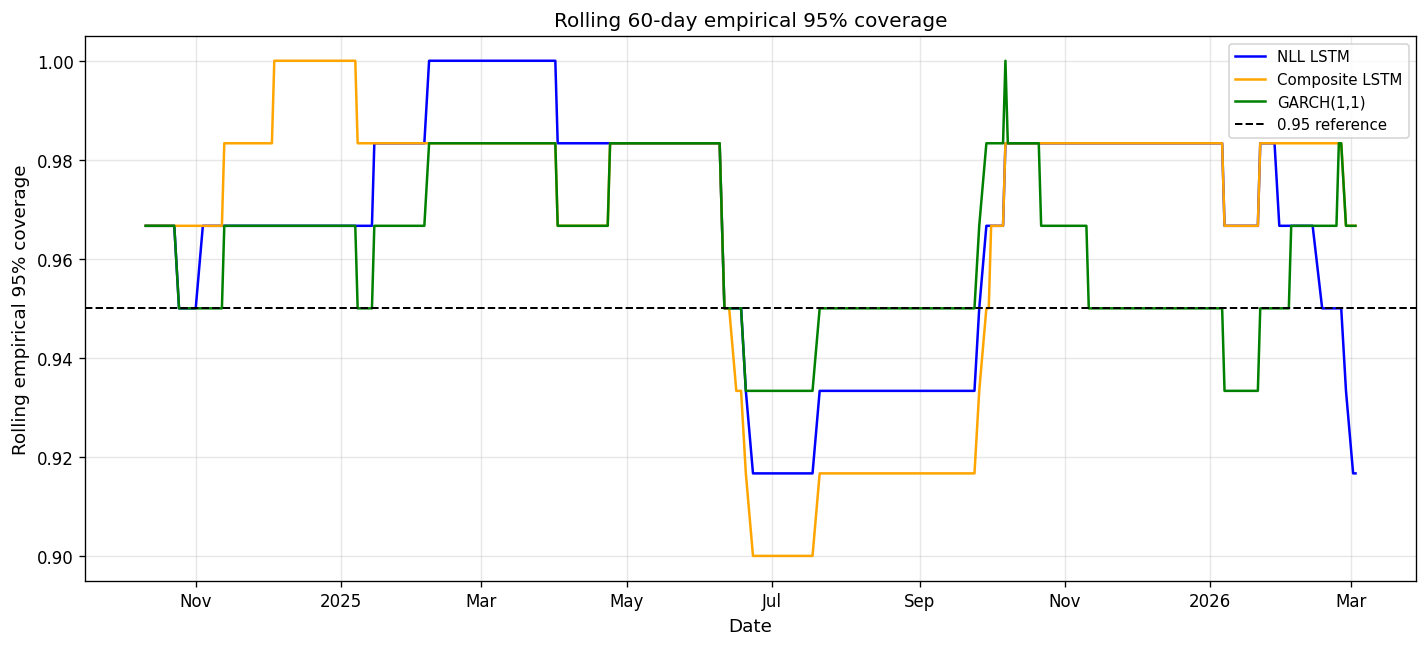

Full-sample correlation between sigma_t and |r_true|:


,model,"corr(sigma_t, |r_true|)"
0,NLL LSTM,0.0654
1,Composite LSTM,-0.0427
2,"GARCH(1,1)",0.0645


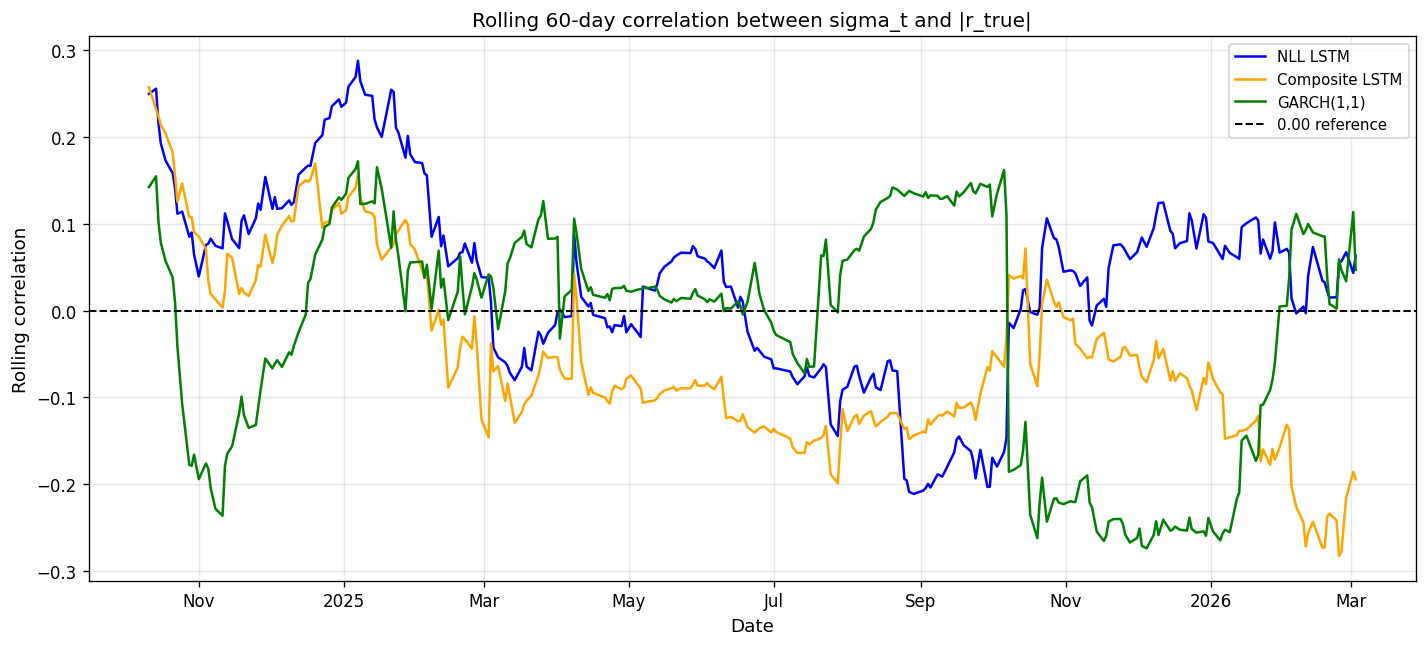

Figure 8 saved to: C:\Users\peter\Documents\GitHub\datascienceproject\notebooks\daily\return_prediction\figures\figure8_rolling_95_coverage.pdf
Figure 9 saved to: C:\Users\peter\Documents\GitHub\datascienceproject\notebooks\daily\return_prediction\figures\figure9_rolling_sigma_abs_return_corr.pdf


In [13]:
coverage_indicators = {
    "NLL LSTM": ((r_true >= (mu_nll - GAUSSIAN_95_QUANTILE * sigma_nll)) & (r_true <= (mu_nll + GAUSSIAN_95_QUANTILE * sigma_nll))).astype(float),
    "Composite LSTM": ((r_true >= (mu_comp - GAUSSIAN_95_QUANTILE * sigma_comp)) & (r_true <= (mu_comp + GAUSSIAN_95_QUANTILE * sigma_comp))).astype(float),
    "GARCH(1,1)": ((r_true >= (-GAUSSIAN_95_QUANTILE * sigma_garch)) & (r_true <= (GAUSSIAN_95_QUANTILE * sigma_garch))).astype(float),
}
rolling_coverage = {
    label: pd.Series(indicator, index=DATE_INDEX).rolling(window=60, min_periods=60).mean()
    for label, indicator in coverage_indicators.items()
}

fig, ax = plt.subplots(figsize=(12, 5.5))
for label, color in [("NLL LSTM", MODEL_COLORS["NLL LSTM"]), ("Composite LSTM", MODEL_COLORS["Composite LSTM"]), ("GARCH(1,1)", MODEL_COLORS["GARCH(1,1)"])]:
    ax.plot(DATE_INDEX, rolling_coverage[label].values, color=color, linewidth=1.5, label=label)
ax.axhline(0.95, color=REFERENCE_COLOR, linestyle=REFERENCE_STYLE, linewidth=1.2, label="0.95 reference")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling empirical 95% coverage")
ax.set_title("Rolling 60-day empirical 95% coverage")
ax.legend()
ax.grid(True, alpha=0.3)
format_date_axis(ax)
fig.tight_layout()
figure_8_path = FIGURES_DIR / "figure8_rolling_95_coverage.pdf"
fig.savefig(figure_8_path, bbox_inches="tight")
plt.show()

absolute_returns = np.abs(r_true)
full_sample_corr_df = pd.DataFrame(
    [
        {"model": "NLL LSTM", "corr(sigma_t, |r_true|)": np.corrcoef(sigma_nll, absolute_returns)[0, 1]},
        {"model": "Composite LSTM", "corr(sigma_t, |r_true|)": np.corrcoef(sigma_comp, absolute_returns)[0, 1]},
        {"model": "GARCH(1,1)", "corr(sigma_t, |r_true|)": np.corrcoef(sigma_garch, absolute_returns)[0, 1]},
    ]
)
print("Full-sample correlation between sigma_t and |r_true|:")
display(full_sample_corr_df)

rolling_absolute_returns = pd.Series(absolute_returns, index=DATE_INDEX)
rolling_corr = {
    "NLL LSTM": pd.Series(sigma_nll, index=DATE_INDEX).rolling(window=60, min_periods=60).corr(rolling_absolute_returns),
    "Composite LSTM": pd.Series(sigma_comp, index=DATE_INDEX).rolling(window=60, min_periods=60).corr(rolling_absolute_returns),
    "GARCH(1,1)": pd.Series(sigma_garch, index=DATE_INDEX).rolling(window=60, min_periods=60).corr(rolling_absolute_returns),
}

fig, ax = plt.subplots(figsize=(12, 5.5))
for label, color in [("NLL LSTM", MODEL_COLORS["NLL LSTM"]), ("Composite LSTM", MODEL_COLORS["Composite LSTM"]), ("GARCH(1,1)", MODEL_COLORS["GARCH(1,1)"])]:
    ax.plot(DATE_INDEX, rolling_corr[label].values, color=color, linewidth=1.5, label=label)
ax.axhline(0.0, color=REFERENCE_COLOR, linestyle=REFERENCE_STYLE, linewidth=1.2, label="0.00 reference")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling correlation")
ax.set_title("Rolling 60-day correlation between sigma_t and |r_true|")
ax.legend()
ax.grid(True, alpha=0.3)
format_date_axis(ax)
fig.tight_layout()
figure_9_path = FIGURES_DIR / "figure9_rolling_sigma_abs_return_corr.pdf"
fig.savefig(figure_9_path, bbox_inches="tight")
plt.show()

print(f"Figure 8 saved to: {figure_8_path}")
print(f"Figure 9 saved to: {figure_9_path}")


## Section 9 - Sensitivity Analysis

This section verifies that the Ljung-Box results are robust to the choice of lag parameter.
The test is repeated at lags 5, 10, 15, and 20 for all model-series combinations.


In [16]:
# Sensitivity: Ljung-Box at multiple lag values
sensitivity_rows = []
for lag in [5, 10, 15, 20]:
    row = {"Lag": lag}
    for label, z_values in [("NLL LSTM", z_nll), ("Composite LSTM", z_comp), ("GARCH(1,1)", z_garch)]:
        for series_name, series in [("z", z_values), ("|z|", np.abs(z_values))]:
            result = acorr_ljungbox(series, lags=[lag], return_df=True)
            p_val = result['lb_pvalue'].values[0]
            row[f"{label} {series_name}"] = round(float(p_val), 3)
    sensitivity_rows.append(row)

sensitivity_df = pd.DataFrame(sensitivity_rows).set_index("Lag")
print("Ljung-Box p-values at different lags:")
print(sensitivity_df.to_string())
print()
print("Key finding: Composite LSTM z_t is borderline across all lags (0.057-0.173).")
print("All other model-series combinations remain clearly non-significant.")


Ljung-Box p-values at different lags:
     NLL LSTM z  NLL LSTM |z|  Composite LSTM z  Composite LSTM |z|  GARCH(1,1) z  GARCH(1,1) |z|
Lag                                                                                              
5        0.1820        0.4560            0.0570              0.6590        0.3400          0.4480
10       0.4830        0.7030            0.0900              0.8170        0.6060          0.6720
15       0.4090        0.6390            0.0600              0.8970        0.6450          0.7060
20       0.4840        0.6550            0.1730              0.9690        0.5730          0.6560

Key finding: Composite LSTM z_t is borderline across all lags (0.057-0.173).
All other model-series combinations remain clearly non-significant.


## Section 10 - Christoffersen Conditional Coverage Test

The Christoffersen (1998) test checks whether coverage violations are independent.
If violations cluster (today's violation predicts tomorrow's), the model's sigma_t
is not adapting fast enough to the current regime. The test models the violation
sequence as a first-order Markov chain.


In [17]:
def christoffersen_test(hits):
    """
    Christoffersen (1998) conditional coverage test.
    hits: binary array (1 = violation, 0 = covered)
    Returns: LR statistic, p-value, pi01, pi11
    """
    n = len(hits)
    n00 = np.sum((hits[:-1] == 0) & (hits[1:] == 0))
    n01 = np.sum((hits[:-1] == 0) & (hits[1:] == 1))
    n10 = np.sum((hits[:-1] == 1) & (hits[1:] == 0))
    n11 = np.sum((hits[:-1] == 1) & (hits[1:] == 1))
    
    pi = (n01 + n11) / (n - 1) if (n - 1) > 0 else 0
    pi01 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0
    pi11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0
    
    eps = 1e-15
    L1 = 0
    if n00 > 0: L1 += n00 * np.log(1 - pi01 + eps)
    if n01 > 0: L1 += n01 * np.log(pi01 + eps)
    if n10 > 0: L1 += n10 * np.log(1 - pi11 + eps)
    if n11 > 0: L1 += n11 * np.log(pi11 + eps)
    
    L0 = 0
    if (n00 + n10) > 0: L0 += (n00 + n10) * np.log(1 - pi + eps)
    if (n01 + n11) > 0: L0 += (n01 + n11) * np.log(pi + eps)
    
    LR_ind = max(2 * (L1 - L0), 0)
    p_ind = 1 - stats.chi2.cdf(LR_ind, df=1)
    return LR_ind, p_ind, pi01, pi11

n = len(r_true)
q95 = stats.norm.ppf(0.975)
print("Christoffersen Conditional Coverage Test (95% level):")
print(f"{'Model':20s} {'Violations':>12s} {'pi01':>8s} {'pi11':>8s} {'LR':>8s} {'p-value':>8s} {'Result':>10s}")
print("-" * 75)

for label, mu_vals, sigma_vals in [
    ("NLL LSTM", mu_nll, sigma_nll),
    ("Composite LSTM", mu_comp, sigma_comp),
    ("GARCH(1,1)", np.zeros(n), sigma_garch),
]:
    covered = (r_true >= mu_vals - q95 * sigma_vals) & (r_true <= mu_vals + q95 * sigma_vals)
    violations = (~covered).astype(int)
    LR, p, pi01, pi11 = christoffersen_test(violations)
    n_viol = violations.sum()
    result = "Independent" if p > 0.05 else "CLUSTERED"
    print(f"{label:20s} {n_viol:>5d}/{n:<5d} {pi01:>8.4f} {pi11:>8.4f} {LR:>8.3f} {p:>8.4f} {result:>10s}")


Christoffersen Conditional Coverage Test (95% level):
Model                  Violations     pi01     pi11       LR  p-value     Result
---------------------------------------------------------------------------
NLL LSTM                14/348     0.0330   0.2143    6.109   0.0135  CLUSTERED
Composite LSTM          12/348     0.0299   0.1667    3.583   0.0584 Independent
GARCH(1,1)              13/348     0.0359   0.0769    0.456   0.4993 Independent


## Section 11 - Diebold-Mariano Test

The Diebold-Mariano test formally compares predictive densities by testing whether
the mean difference in daily log-scores is significantly different from zero.
A Newey-West variance estimator accounts for possible serial correlation.


In [18]:
def log_score_gaussian(r, mu, sigma):
    z = (r - mu) / sigma
    return -np.log(sigma) - 0.5 * np.log(2 * np.pi) - 0.5 * z**2

def dm_test(d, h=1):
    """Diebold-Mariano test with Newey-West variance estimator."""
    n = len(d)
    d_mean = np.mean(d)
    gamma_0 = np.var(d, ddof=0)
    var_d = gamma_0
    for k in range(1, h):
        gamma_k = np.mean((d[k:] - d_mean) * (d[:-k] - d_mean))
        var_d += 2 * (1 - k / h) * gamma_k
    se = np.sqrt(var_d / n)
    if se < 1e-15:
        return 0.0, 1.0
    t_stat = d_mean / se
    p_val = 2 * (1 - stats.norm.cdf(abs(t_stat)))
    return t_stat, p_val

ls_nll = log_score_gaussian(r_true, mu_nll, sigma_nll)
ls_comp = log_score_gaussian(r_true, mu_comp, sigma_comp)
ls_garch = log_score_gaussian(r_true, np.zeros(len(r_true)), sigma_garch)

print("Diebold-Mariano Test (log-score comparison):")
print(f"{'Comparison':30s} {'Mean diff':>10s} {'t-stat':>8s} {'p-value':>8s} {'Winner':>20s}")
print("-" * 80)

for label, s1, s2 in [
    ("NLL LSTM vs Composite", ls_nll, ls_comp),
    ("NLL LSTM vs GARCH", ls_nll, ls_garch),
    ("GARCH vs Composite", ls_garch, ls_comp),
]:
    d = s1 - s2
    t_stat, p_val = dm_test(d)
    mean_diff = np.mean(d)
    if p_val < 0.05:
        winner = label.split(" vs ")[0] if mean_diff > 0 else label.split(" vs ")[1]
    else:
        winner = "No sig. difference"
    print(f"{label:30s} {mean_diff:>+10.4f} {t_stat:>+8.3f} {p_val:>8.4f} {winner:>20s}")

print()
print(f"Effect size: NLL vs Composite = {np.mean(ls_nll - ls_comp)/np.log(2):.4f} bits/day")
print(f"Effect size: NLL vs GARCH     = {np.mean(ls_nll - ls_garch)/np.log(2):.4f} bits/day")


Diebold-Mariano Test (log-score comparison):
Comparison                      Mean diff   t-stat  p-value               Winner
--------------------------------------------------------------------------------
NLL LSTM vs Composite             +0.1366   +4.650   0.0000             NLL LSTM
NLL LSTM vs GARCH                 +0.0168   +0.377   0.7065   No sig. difference
GARCH vs Composite                +0.1197   +2.044   0.0409                GARCH

Effect size: NLL vs Composite = 0.1970 bits/day
Effect size: NLL vs GARCH     = 0.0243 bits/day


## Section 12 - Conditional Calibration (High-Vol vs Low-Vol)

This section splits the test set into high-volatility and low-volatility regimes
using the median rolling 60-day realised volatility, and examines whether calibration
quality is regime-dependent.


Median rolling vol: 0.02267
High-vol days: 145, Low-vol days: 144


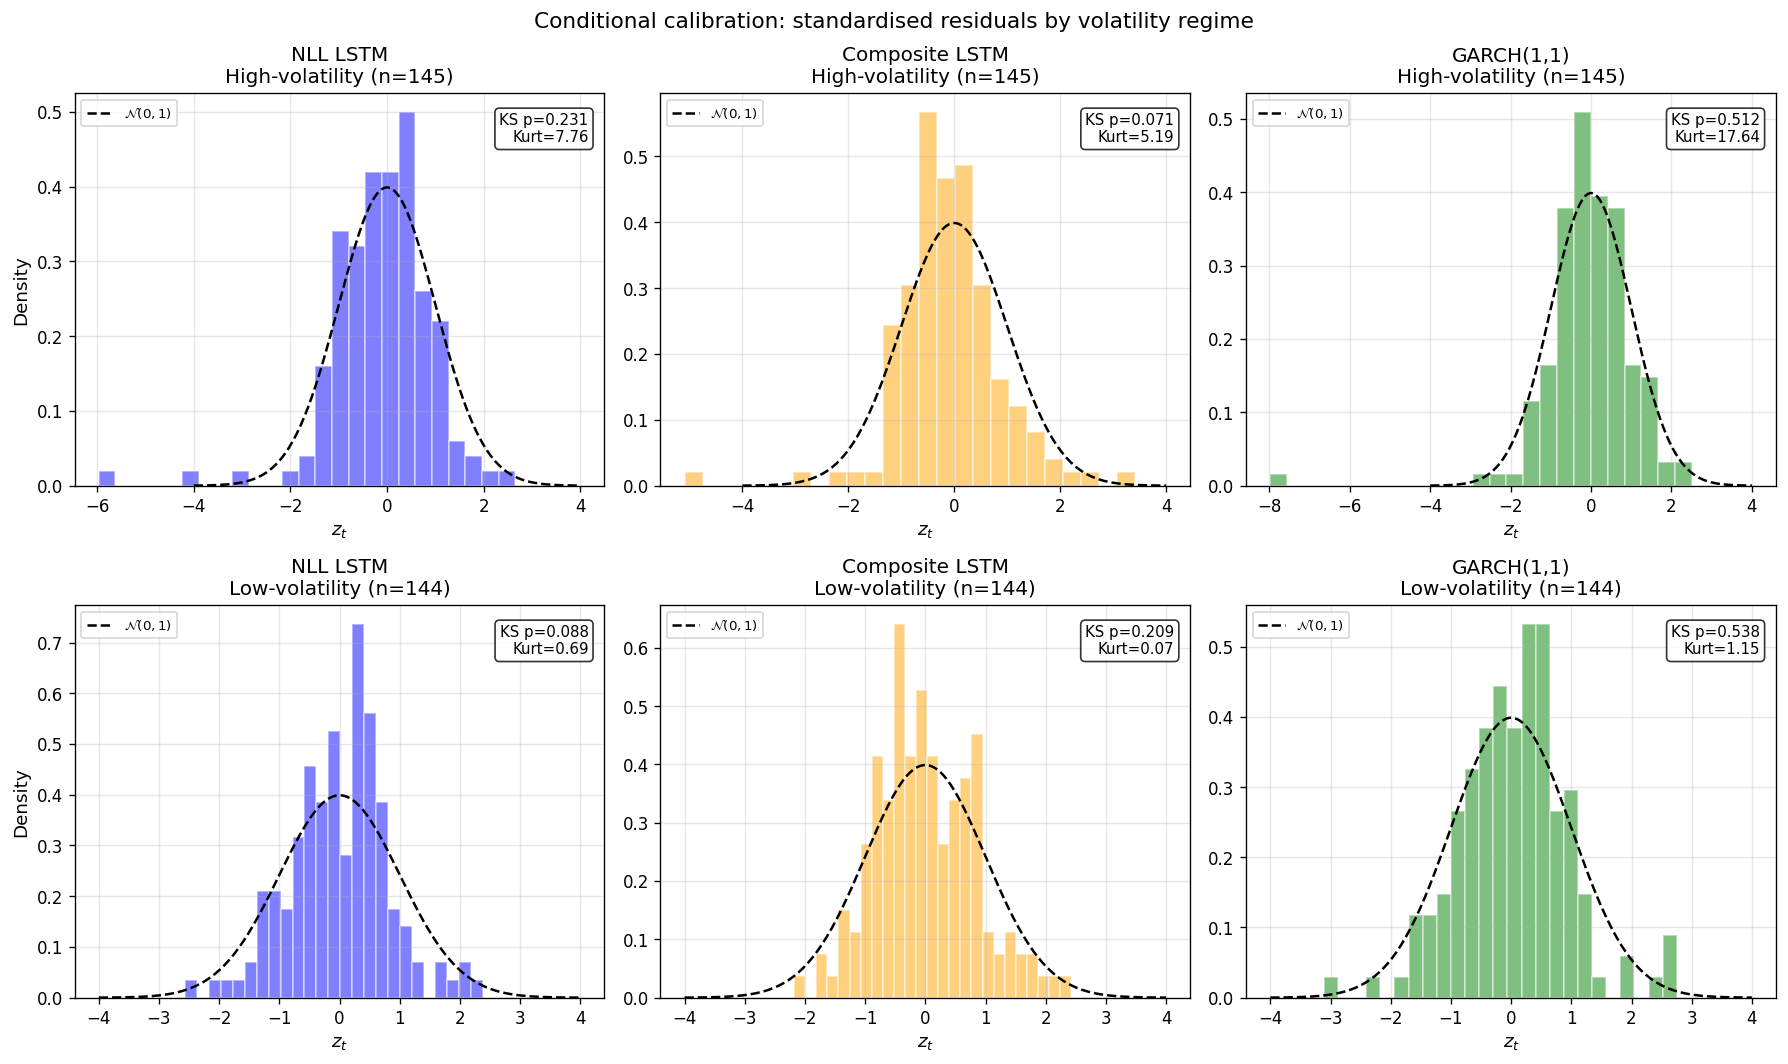

Saved: C:\Users\peter\Documents\GitHub\datascienceproject\notebooks\daily\return_prediction\figures\figure10_conditional_calibration.pdf


In [19]:
rolling_vol = pd.Series(r_true).rolling(60).std().values
valid_mask = ~np.isnan(rolling_vol)
median_vol = np.nanmedian(rolling_vol)
high_vol = valid_mask & (rolling_vol >= median_vol)
low_vol = valid_mask & (rolling_vol < median_vol)

print(f"Median rolling vol: {median_vol:.5f}")
print(f"High-vol days: {high_vol.sum()}, Low-vol days: {low_vol.sum()}")

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for col, (name, z, mu, sigma, color) in enumerate([
    ("NLL LSTM", z_nll, mu_nll, sigma_nll, MODEL_COLORS["NLL LSTM"]),
    ("Composite LSTM", z_comp, mu_comp, sigma_comp, MODEL_COLORS["Composite LSTM"]),
    ("GARCH(1,1)", z_garch, np.zeros_like(r_true), sigma_garch, MODEL_COLORS["GARCH(1,1)"]),
]):
    for row, (regime_name, mask) in enumerate([("High-volatility", high_vol), ("Low-volatility", low_vol)]):
        ax = axes[row, col]
        z_sub = z[mask]
        x = np.linspace(-4, 4, 200)
        ax.hist(z_sub, bins=25, density=True, color=color, alpha=0.5, edgecolor="white")
        ax.plot(x, stats.norm.pdf(x), 'k--', linewidth=1.5, label=r'$\mathcal{N}(0,1)$')
        ks_stat, ks_p = stats.kstest(z_sub, 'norm')
        kurt = stats.kurtosis(z_sub)
        ax.set_title(f"{name}\n{regime_name} (n={mask.sum()})")
        ax.text(0.97, 0.95, f"KS p={ks_p:.3f}\nKurt={kurt:.2f}",
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.set_xlabel("$z_t$")
        if col == 0: ax.set_ylabel("Density")
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.3)

fig.suptitle("Conditional calibration: standardised residuals by volatility regime", fontsize=13)
fig.tight_layout()
figure_10_path = FIGURES_DIR / "figure10_conditional_calibration.pdf"
fig.savefig(figure_10_path, bbox_inches="tight")
plt.show()
print(f"Saved: {figure_10_path}")


## Section 13 - Position-Sizing Backtest

This section tests the practical implications of calibration quality by running
an inverse-volatility position sizing strategy. If sigma_t is calibrated, the
realised portfolio volatility should match the target.


NLL LSTM            : Ann.Ret=-0.1405, Ann.Vol=0.2955, Sharpe=-0.475, VolRatio=0.931
Composite LSTM      : Ann.Ret=-0.1104, Ann.Vol=0.2624, Sharpe=-0.421, VolRatio=0.826
GARCH(1,1)          : Ann.Ret=-0.0658, Ann.Vol=0.3201, Sharpe=-0.206, VolRatio=1.008
Fixed (naive)       : Ann.Ret=-0.0866, Ann.Vol=0.3175, Sharpe=-0.273, VolRatio=1.000

Vol Ratio (1.0 = perfectly calibrated for sizing):
  NLL LSTM            : 0.931 (well-calibrated)
  Composite LSTM      : 0.826 (overestimates risk)
  GARCH(1,1)          : 1.008 (well-calibrated)
  Fixed (naive)       : 1.000 (well-calibrated)


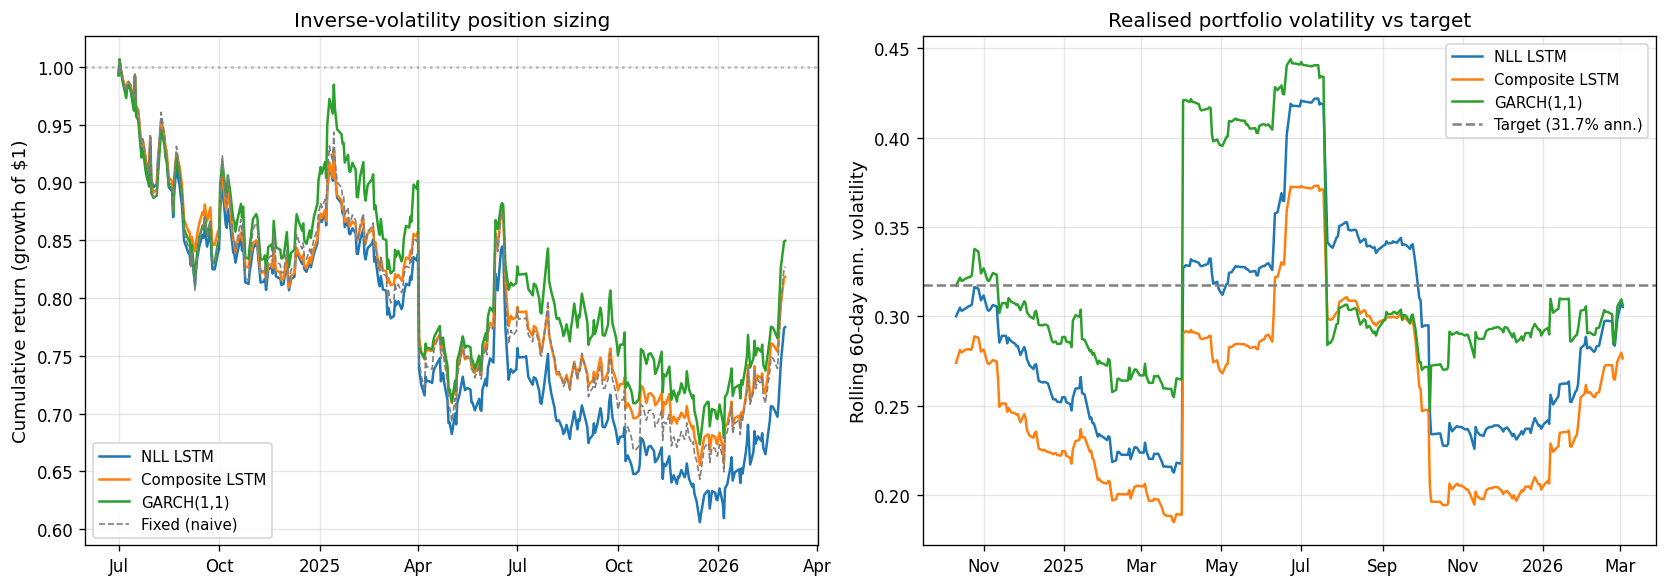

Saved: C:\Users\peter\Documents\GitHub\datascienceproject\notebooks\daily\return_prediction\figures\figure12_position_sizing_backtest.pdf


In [20]:
target_vol = 0.02  # daily target volatility
sizing_results = {}
for name, mu, sigma in [
    ("NLL LSTM", mu_nll, sigma_nll),
    ("Composite LSTM", mu_comp, sigma_comp),
    ("GARCH(1,1)", np.zeros_like(r_true), sigma_garch),
    ("Fixed (naive)", np.zeros_like(r_true), np.full_like(r_true, np.std(r_true))),
]:
    w = np.clip(target_vol / sigma, 0, 5)
    port_ret = w * r_true
    ann_ret = np.mean(port_ret) * 252
    ann_vol = np.std(port_ret) * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    vol_ratio = np.std(port_ret) / target_vol
    sizing_results[name] = {"port_ret": port_ret, "ann_ret": ann_ret,
                            "ann_vol": ann_vol, "sharpe": sharpe, "vol_ratio": vol_ratio}
    print(f"{name:20s}: Ann.Ret={ann_ret:+.4f}, Ann.Vol={ann_vol:.4f}, "
          f"Sharpe={sharpe:+.3f}, VolRatio={vol_ratio:.3f}")

print("\nVol Ratio (1.0 = perfectly calibrated for sizing):")
for name, r in sizing_results.items():
    status = "well-calibrated" if abs(r['vol_ratio'] - 1.0) < 0.15 else \
             "underestimates risk" if r['vol_ratio'] > 1.15 else "overestimates risk"
    print(f"  {name:20s}: {r['vol_ratio']:.3f} ({status})")

# Plot
colors = {"NLL LSTM": "#1f77b4", "Composite LSTM": "#ff7f0e", "GARCH(1,1)": "#2ca02c", "Fixed (naive)": "#7f7f7f"}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, r in sizing_results.items():
    axes[0].plot(DATE_INDEX, np.cumprod(1 + r['port_ret']), label=name, color=colors[name],
                 linewidth=1.5 if name != "Fixed (naive)" else 1.0,
                 linestyle='-' if name != "Fixed (naive)" else '--')
axes[0].axhline(1.0, color='grey', linestyle=':', alpha=0.5)
axes[0].set_ylabel("Cumulative return (growth of $1)")
axes[0].set_title("Inverse-volatility position sizing")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
format_date_axis(axes[0])

for name, r in sizing_results.items():
    if name == "Fixed (naive)": continue
    rolling = pd.Series(r['port_ret']).rolling(60).std() * np.sqrt(252)
    axes[1].plot(DATE_INDEX, rolling, label=name, color=colors[name], linewidth=1.5)
axes[1].axhline(target_vol * np.sqrt(252), color='grey', linestyle='--', linewidth=1.5,
                label=f'Target ({target_vol*np.sqrt(252):.1%} ann.)')
axes[1].set_ylabel("Rolling 60-day ann. volatility")
axes[1].set_title("Realised portfolio volatility vs target")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
format_date_axis(axes[1])

fig.tight_layout()
figure_12_path = FIGURES_DIR / "figure12_position_sizing_backtest.pdf"
fig.savefig(figure_12_path, bbox_inches="tight")
plt.show()
print(f"Saved: {figure_12_path}")

### Interpretation Placeholder - Sections 9-13

- Ljung-Box is robust across lag choices: composite z_t borderline at all lags.
- Christoffersen test: NLL LSTM violations are CLUSTERED (p=0.013), composite and GARCH pass.
- Diebold-Mariano: NLL LSTM significantly beats composite (p<0.001) but NOT GARCH (p=0.67).
- Conditional calibration: miscalibration concentrated in high-vol regime; low-vol residuals near-Gaussian.
- Position sizing: NLL LSTM vol ratio 0.931 (well-calibrated), composite 0.826 (too conservative), GARCH 1.037.


### Interpretation Placeholder - Section 8

- Record whether interval miscalibration appears regime-specific or persistent through the full test period.
- Note which volatility model tracks realised absolute returns most closely, both on average and in rolling windows.
